# Загрузка данных

Данные взяты с сайта kaggle
[банковские транзакции](https://www.kaggle.com/datasets/shivamb/bank-customer-segmentation)

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Z Аналитик данных ISA/Python/PN_14/bank_clients_transactions.csv')

In [56]:
df

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,"17,819.05",2/8/16,143207,25.00
1,T2,C2142763,4/4/57,M,JHAJJAR,"2,270.69",2/8/16,141858,"27,999.00"
2,T3,C4417068,26/11/96,F,MUMBAI,"17,874.44",2/8/16,142712,459.00
3,T4,C5342380,14/9/73,F,MUMBAI,"866,503.21",2/8/16,142714,"2,060.00"
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,"6,714.43",2/8/16,181156,"1,762.50"
...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,8/4/90,M,NEW DELHI,"7,635.19",18/9/16,184824,799.00
1048563,T1048564,C6459278,20/2/92,M,NASHIK,"27,311.42",18/9/16,183734,460.00
1048564,T1048565,C6412354,18/5/89,M,HYDERABAD,"221,757.06",18/9/16,183313,770.00
1048565,T1048566,C6420483,30/8/78,M,VISAKHAPATNAM,"10,117.87",18/9/16,184706,"1,000.00"


In [57]:
# Выводим информацию по датафрейму
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


# Приведение столбцов к стилю camel_case

In [58]:
# Словарь для переименования столбцов в стиле camelCase
rename_dict = {
    'TransactionID': 'transactionId',
    'CustomerID': 'customerId',
    'CustomerDOB': 'customerDob',
    'CustGender': 'custGender',
    'CustLocation': 'custLocation',
    'CustAccountBalance': 'custAccountBalance',
    'TransactionDate': 'transactionDate',
    'TransactionTime': 'transactionTime',
    'TransactionAmount (INR)': 'transactionAmountInr'
}

# Применяем переименование
df = df.rename(columns=rename_dict)

# Проверяем результат
print(df.columns.tolist())

['transactionId', 'customerId', 'customerDob', 'custGender', 'custLocation', 'custAccountBalance', 'transactionDate', 'transactionTime', 'transactionAmountInr']


# Приведение типов данных

In [59]:
#привести дату к типу datetime

# Посмотрим первые уникальные значения
print("Примеры значений в customerDob:")
print(df['customerDob'].dropna().head(15).tolist())

# Посчитаем разные форматы (гипотетически)
print("\nСтатистика по разделителям:")
print(df['customerDob'].str.contains('-').sum(), "значений с '-' (гггг-мм-дд)")
print(df['customerDob'].str.contains('/').sum(), "значений с '/' (дд/мм/гггг или мм/дд/гггг)")

Примеры значений в customerDob:
['10/1/94', '4/4/57', '26/11/96', '14/9/73', '24/3/88', '8/10/72', '26/1/92', '27/1/82', '19/4/88', '22/6/84', '22/7/82', '7/7/88', '13/6/78', '5/1/92', '24/3/78']

Статистика по разделителям:
0 значений с '-' (гггг-мм-дд)
1045170 значений с '/' (дд/мм/гггг или мм/дд/гггг)


In [60]:
# Преобразуем с явным указанием формата и дня первым
df['customerDob'] = pd.to_datetime(
    df['customerDob'],
    format='%d/%m/%y',   # двухзначный год: 94 → 1994/2094
    dayfirst=True,       # день идёт первым: 10/1/94 → 10 января
    errors='coerce'
)

# Исправляем "даты из будущего" (например, 2057 → 1957)
current_date = pd.Timestamp('2026-02-16')
future_mask = df['customerDob'] > current_date
df.loc[future_mask, 'customerDob'] = df.loc[future_mask, 'customerDob'] - pd.DateOffset(years=100)

# Проверяем результат
print("Примеры после преобразования:")
print(df['customerDob'].head(15))
print("\nСтатистика:")
print(f"Всего пропусков: {df['customerDob'].isnull().sum()}")
print(f"Дат из будущего (до исправления): {(df['customerDob'] > current_date).sum()}")
print(f"Минимальная дата рождения: {df['customerDob'].min()}")
print(f"Максимальная дата рождения: {df['customerDob'].max()}")

Примеры после преобразования:
0    1994-01-10
1    1957-04-04
2    1996-11-26
3    1973-09-14
4    1988-03-24
5    1972-10-08
6    1992-01-26
7    1982-01-27
8    1988-04-19
9    1984-06-22
10   1982-07-22
11   1988-07-07
12   1978-06-13
13   1992-01-05
14   1978-03-24
Name: customerDob, dtype: datetime64[ns]

Статистика:
Всего пропусков: 60736
Дат из будущего (до исправления): 0
Минимальная дата рождения: 1926-03-14 00:00:00
Максимальная дата рождения: 2026-01-28 00:00:00


In [61]:
df

,transactionId,customerId,customerDob,custGender,custLocation,custAccountBalance,transactionDate,transactionTime,transactionAmountInr
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,"17,819.05",2/8/16,143207,25.00
1,T2,C2142763,1957-04-04,M,JHAJJAR,"2,270.69",2/8/16,141858,"27,999.00"
2,T3,C4417068,1996-11-26,F,MUMBAI,"17,874.44",2/8/16,142712,459.00
3,T4,C5342380,1973-09-14,F,MUMBAI,"866,503.21",2/8/16,142714,"2,060.00"
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,"6,714.43",2/8/16,181156,"1,762.50"
...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990-04-08,M,NEW DELHI,"7,635.19",18/9/16,184824,799.00
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,"27,311.42",18/9/16,183734,460.00
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,"221,757.06",18/9/16,183313,770.00
1048565,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,"10,117.87",18/9/16,184706,"1,000.00"


In [62]:
# Быстрая диагностика формата
print("Первые 10:")
print(df['transactionDate'].head(10).tolist())

print("\nСтатистика по символам:")
print("С дефисом '-':", df['transactionDate'].str.contains('-').sum())
print("Со слэшем '/':", df['transactionDate'].str.contains('/').sum())
print("С нулевой датой:", (df['transactionDate'] == '0000-00-00').sum())


Первые 10:
['2/8/16', '2/8/16', '2/8/16', '2/8/16', '2/8/16', '2/8/16', '2/8/16', '2/8/16', '2/8/16', '2/8/16']

Статистика по символам:
С дефисом '-': 0
Со слэшем '/': 1048567
С нулевой датой: 0


In [63]:
# Преобразуем с учётом формата дд/мм/гг
df['transactionDate'] = pd.to_datetime(
    df['transactionDate'],
    format='%d/%m/%y',   # двухзначный год: 16 → 2016
    dayfirst=True,       # день первым: 2/8/16 → 2 августа
    errors='coerce'
)

# Проверяем результат
print("Примеры после преобразования transactionDate:")
print(df['transactionDate'].head(10))
print("\nПропусков в transactionDate:", df['transactionDate'].isnull().sum())

Примеры после преобразования transactionDate:
0   2016-08-02
1   2016-08-02
2   2016-08-02
3   2016-08-02
4   2016-08-02
5   2016-08-02
6   2016-08-02
7   2016-08-02
8   2016-08-02
9   2016-08-02
Name: transactionDate, dtype: datetime64[ns]

Пропусков в transactionDate: 0


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transactionId         1048567 non-null  object        
 1   customerId            1048567 non-null  object        
 2   customerDob           987831 non-null   datetime64[ns]
 3   custGender            1047467 non-null  object        
 4   custLocation          1048416 non-null  object        
 5   custAccountBalance    1046198 non-null  float64       
 6   transactionDate       1048567 non-null  datetime64[ns]
 7   transactionTime       1048567 non-null  int64         
 8   transactionAmountInr  1048567 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(4)
memory usage: 72.0+ MB


# Поиск дублей и пропусков в данных

In [66]:
print("ПРОВЕРКА ДУБЛИКАТОВ")

# Полные дубликаты строк (все 9 столбцов)
full_dup = df.duplicated().sum()
print(f" Полных дубликатов строк: {full_dup:,}")

# Дубликаты по уникальному ID транзакции (КРИТИЧНО!)
trans_id_dup = df['transactionId'].duplicated().sum()
print(f" Дубликатов transactionId: {trans_id_dup:,}")

# Дубликаты по связке: клиент + дата + время + сумма
# (максимально строгая проверка повторных транзакций)
dup_strict = df.duplicated(
    subset=['customerId', 'transactionDate', 'transactionTime', 'transactionAmountInr']
).sum()
print(f" Дубликатов (клиент + дата + время + сумма): {dup_strict:,}")

# Дубликаты по связке: клиент + дата + время (без суммы)
dup_time = df.duplicated(
    subset=['customerId', 'transactionDate', 'transactionTime']
).sum()
print(f" Дубликатов (клиент + дата + время): {dup_time:,}")

# Итоговый вердикт
print("\n" + "="*60)
if full_dup == 0 and trans_id_dup == 0 and dup_strict == 0:
    print("ДУБЛИКАТОВ НЕ ОБНАРУЖЕНО! Данные чистые.")
else:
    print("Обнаружены дубликаты! Требуется анализ.")
    # Показываем примеры при наличии
    if trans_id_dup > 0:
        print("\n Примеры дубликатов по transactionId:")
        dup_ids = df[df['transactionId'].duplicated(keep=False)]['transactionId'].unique()[:2]
        print(df[df['transactionId'].isin(dup_ids)][
            ['transactionId', 'customerId', 'transactionDate', 'transactionTime', 'transactionAmountInr']
        ].head(4))

    if dup_strict > 0:
        print("\n Примеры полных дубликатов по деталям транзакции:")
        mask = df.duplicated(
            subset=['customerId', 'transactionDate', 'transactionTime', 'transactionAmountInr'],
            keep=False
        )
        print(df[mask][
            ['customerId', 'transactionDate', 'transactionTime', 'transactionAmountInr']
        ].head(4))
print("="*60)

ПРОВЕРКА ДУБЛИКАТОВ
 Полных дубликатов строк: 0
 Дубликатов transactionId: 0
 Дубликатов (клиент + дата + время + сумма): 0
 Дубликатов (клиент + дата + время): 0

ДУБЛИКАТОВ НЕ ОБНАРУЖЕНО! Данные чистые.


In [67]:
import numpy as np

print("АНАЛИЗ ПРОПУСКОВ")

# Собираем статистику
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(3)
total_cells = df.shape[0] * df.shape[1]
total_missing = missing.sum()

# Формируем отчёт
report = pd.DataFrame({
    'Столбец': df.columns,
    'Тип данных': df.dtypes,
    'Пропусков': missing,
    '% пропусков': missing_pct,
    'Заполнено': df.notnull().sum(),
    '% заполнено': (100 - missing_pct).round(3)
})

# Сортируем по количеству пропусков (убывание)
report = report.sort_values('Пропусков', ascending=False).reset_index(drop=True)

# Показываем только столбцы с пропусками
print("\n Столбцы с пропусками:\n")
print(report[report['Пропусков'] > 0].to_string(index=False))

# Итоговая статистика
print("\n" + "-"*70)
print(f" Всего строк: {len(df):,}")
print(f" Всего столбцов: {df.shape[1]}")
print(f" Всего пропущенных значений: {total_missing:,}")
print(f" Доля пропусков во всём датафрейме: {(total_missing/total_cells*100):.3f}%")
print("-"*70)

АНАЛИЗ ПРОПУСКОВ

 Столбцы с пропусками:

           Столбец     Тип данных  Пропусков  % пропусков  Заполнено  % заполнено
       customerDob datetime64[ns]      60736         5.79     987831        94.21
custAccountBalance        float64       2369         0.23    1046198        99.77
        custGender         object       1100         0.10    1047467        99.89
      custLocation         object        151         0.01    1048416        99.99

----------------------------------------------------------------------
 Всего строк: 1,048,567
 Всего столбцов: 9
 Всего пропущенных значений: 64,356
 Доля пропусков во всём датафрейме: 0.682%
----------------------------------------------------------------------


In [68]:
# Посмотрим распределение gender до заполнения
print("\nРаспределение поля до заполнения пропусков:")
print(df['custGender'].value_counts(dropna=False))
print("\nМода:", df['custGender'].mode()[0])


Распределение поля до заполнения пропусков:
custGender
M      765530
F      281936
NaN      1100
T           1
Name: count, dtype: int64

Мода: M


In [69]:
# Создаём копию для безопасности + фиксируем seed
df_clean = df.copy()
np.random.seed(2026)  # для полной воспроизводимости

# Шаг 1:custLocation — удаляем строки (минимум потерь)

before_loc = len(df_clean)
df_clean = df_clean.dropna(subset=['custLocation'])
after_loc = len(df_clean)
print(f"custLocation: удалено {before_loc - after_loc:,} строк ({(before_loc-after_loc)/before_loc*100:.3f}%)")

# ШАГ 2: Обработка custGender (замена 'T' + пропорциональное заполнение)

# Заменяем редкое значение 'T' на 'F'
if 'T' in df_clean['custGender'].unique():
    t_count = (df_clean['custGender'] == 'T').sum()
    df_clean['custGender'] = df_clean['custGender'].replace('T', 'F')
    print(f"Значение 'T' заменено на 'F' ({t_count} запись)")

# Рассчитываем пропорции только на валидных 'M'/'F' (после удаления строк и замены 'T')
valid_gender = df_clean['custGender'].dropna()
m_count = (valid_gender == 'M').sum()
f_count = (valid_gender == 'F').sum()
total_valid = m_count + f_count
m_ratio = m_count / total_valid
f_ratio = f_count / total_valid

print(f"\n Распределение гендера до заполнения:")
print(f"   M: {m_count:,} ({m_ratio*100:.2f}%)")
print(f"   F: {f_count:,} ({f_ratio*100:.2f}%)")

# Находим индексы пропусков
missing_gender_idx = df_clean[df_clean['custGender'].isnull()].index.tolist()
n_missing = len(missing_gender_idx)

# Формируем пропорциональные значения
fill_values = np.random.choice(
    ['M', 'F'],
    size=n_missing,
    p=[m_ratio, f_ratio]
)

# Заполняем
df_clean.loc[missing_gender_idx, 'custGender'] = fill_values

# Проверка
post_fill = df_clean['custGender'].value_counts(normalize=True)
print(f"\n Распределение гендера после заполнения:")
print(f"   M: {post_fill.get('M', 0)*100:.2f}%")
print(f"   F: {post_fill.get('F', 0)*100:.2f}%")
print(f"   Пропусков: {df_clean['custGender'].isnull().sum()}")


# ШАГ 3: Заполняем пропуски в балансе медианой

median_balance = df_clean['custAccountBalance'].median()
filled_balance = df_clean['custAccountBalance'].isnull().sum()
df_clean['custAccountBalance'] = df_clean['custAccountBalance'].fillna(median_balance)
print(f"\n custAccountBalance: заполнено {filled_balance:,} пропусков медианой = {median_balance:,.2f} INR")


# ШАГ 4: customerDob — создаём флаг пропуска (без заполнения)
# Пропуски оставлены как есть (корректнее для даты рождения)
missing_dob = df_clean['customerDob'].isnull().sum()
df_clean['isDobMissing'] = df_clean['customerDob'].isnull().astype(int)
print(f"\n customerDob: создан флаг 'isDobMissing' для {missing_dob:,} пропусков ({missing_dob/len(df_clean)*100:.3f}%)")

# ФИНАЛЬНАЯ ПРОВЕРКА

print(" ИТОГ")
print(f"Исходных строк: {len(df):,}")
print(f"Осталось строк: {len(df_clean):,} (-{(len(df)-len(df_clean))/len(df)*100:.3f}%)")
print(f"Всего пропусков до: {df.isnull().sum().sum():,}")
print(f"Всего пропусков после: {df_clean.isnull().sum().sum():,}")

# Детальный отчёт по пропускам
final_missing = df_clean.isnull().sum()
if final_missing.sum() > 0:
    print("\n  Оставшиеся пропуски:")
    print(final_missing[final_missing > 0])
else:
    print("\n Все пропуски обработаны ")

# Проверка распределения гендера (финал)
print("\n Финальное распределение гендера:")
print(df_clean['custGender'].value_counts().to_string())




custLocation: удалено 151 строк (0.014%)
Значение 'T' заменено на 'F' (1 запись)

 Распределение гендера до заполнения:
   M: 765,410 (73.08%)
   F: 281,906 (26.92%)

 Распределение гендера после заполнения:
   M: 73.08%
   F: 26.92%
   Пропусков: 0

 custAccountBalance: заполнено 2,369 пропусков медианой = 16,792.18 INR

 customerDob: создан флаг 'isDobMissing' для 60,736 пропусков (5.793%)
 ИТОГ
Исходных строк: 1,048,567
Осталось строк: 1,048,416 (-0.014%)
Всего пропусков до: 64,356
Всего пропусков после: 60,736

  Оставшиеся пропуски:
customerDob    60736
dtype: int64

 Финальное распределение гендера:
custGender
M    766208
F    282208


In [70]:
# Дополняем время до 6 цифр (930 → 000930)
df_clean['transactionTimeStr'] = df_clean['transactionTime'].astype(str).str.zfill(6)

# Создаём полный временной штамп (дата + время)
df_clean['transactionDateTime'] = pd.to_datetime(
    df_clean['transactionDate'].dt.strftime('%Y-%m-%d') + ' ' + df_clean['transactionTimeStr'],
    format='%Y-%m-%d %H%M%S',
    errors='coerce'  # некорректное время → NaT
)

# Удаляем временный столбец
df_clean.drop('transactionTimeStr', axis=1, inplace=True)

# Проверяем результат

print(" Примеры transactionDateTime:")
print(df_clean[['transactionDate', 'transactionTime', 'transactionDateTime']].head(5))
print(f"\n Некорректных временных штампов: {df_clean['transactionDateTime'].isnull().sum()}")

 Примеры transactionDateTime:
  transactionDate  transactionTime transactionDateTime
0      2016-08-02           143207 2016-08-02 14:32:07
1      2016-08-02           141858 2016-08-02 14:18:58
2      2016-08-02           142712 2016-08-02 14:27:12
3      2016-08-02           142714 2016-08-02 14:27:14
4      2016-08-02           181156 2016-08-02 18:11:56

 Некорректных временных штампов: 0


In [71]:
df=df_clean
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1048416 entries, 0 to 1048566
Data columns (total 11 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transactionId         1048416 non-null  object        
 1   customerId            1048416 non-null  object        
 2   customerDob           987680 non-null   datetime64[ns]
 3   custGender            1048416 non-null  object        
 4   custLocation          1048416 non-null  object        
 5   custAccountBalance    1048416 non-null  float64       
 6   transactionDate       1048416 non-null  datetime64[ns]
 7   transactionTime       1048416 non-null  int64         
 8   transactionAmountInr  1048416 non-null  float64       
 9   isDobMissing          1048416 non-null  int64         
 10  transactionDateTime   1048416 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(2), object(4)
memory usage: 128.2+ MB


# Исследовательский анализ данных

In [72]:
df

,transactionId,customerId,customerDob,custGender,custLocation,custAccountBalance,transactionDate,transactionTime,transactionAmountInr,isDobMissing,transactionDateTime
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,"17,819.05",2016-08-02,143207,25.00,0,2016-08-02 14:32:07
1,T2,C2142763,1957-04-04,M,JHAJJAR,"2,270.69",2016-08-02,141858,"27,999.00",0,2016-08-02 14:18:58
2,T3,C4417068,1996-11-26,F,MUMBAI,"17,874.44",2016-08-02,142712,459.00,0,2016-08-02 14:27:12
3,T4,C5342380,1973-09-14,F,MUMBAI,"866,503.21",2016-08-02,142714,"2,060.00",0,2016-08-02 14:27:14
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,"6,714.43",2016-08-02,181156,"1,762.50",0,2016-08-02 18:11:56
...,...,...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990-04-08,M,NEW DELHI,"7,635.19",2016-09-18,184824,799.00,0,2016-09-18 18:48:24
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,"27,311.42",2016-09-18,183734,460.00,0,2016-09-18 18:37:34
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,"221,757.06",2016-09-18,183313,770.00,0,2016-09-18 18:33:13
1048565,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,"10,117.87",2016-09-18,184706,"1,000.00",0,2016-09-18 18:47:06


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1048416 entries, 0 to 1048566
Data columns (total 11 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transactionId         1048416 non-null  object        
 1   customerId            1048416 non-null  object        
 2   customerDob           987680 non-null   datetime64[ns]
 3   custGender            1048416 non-null  object        
 4   custLocation          1048416 non-null  object        
 5   custAccountBalance    1048416 non-null  float64       
 6   transactionDate       1048416 non-null  datetime64[ns]
 7   transactionTime       1048416 non-null  int64         
 8   transactionAmountInr  1048416 non-null  float64       
 9   isDobMissing          1048416 non-null  int64         
 10  transactionDateTime   1048416 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(2), object(4)
memory usage: 128.2+ MB


In [74]:
# сколько уникальных клиентов?

total_customers = df['customerId'].nunique()

print(f" Уникальных клиентов: {total_customers:,}")

 Уникальных клиентов: 884,151


In [75]:
# какое количество транзакций было совершено?

total_transactions = len(df)

print(f" Всего транзакций: {total_transactions:,}")

 Всего транзакций: 1,048,416


In [76]:
# сколько в среднем транзакций приходится на одного клиента?
print(f" В среднем транзакций приходится на одного клиента: {total_transactions / total_customers:.2f}")

 В среднем транзакций приходится на одного клиента: 1.19


 Обработано записей: 1,048,416
 Баланс счёта клиента
Count          : 1,048,416
Mean           : 115,184.13
Median         : 16,792.18
Std            : 845,600.95
Min            : 0.00
Max            : 115,035,495.10
Range          : 115,035,495.10
Q1             : 4,740.53
Q3             : 57,472.88
IQR            : 52,732.35
Skewness       : 60.59
Kurtosis       : 5,842.17
P95            : 415,339.18
P99            : 1,586,508.61
Outliers_IQR   : 141,190
 Сумма транзакции
Count          : 1,048,416
Mean           : 1,574.33
Median         : 459.04
Std            : 6,575.10
Min            : 0.00
Max            : 1,560,034.99
Range          : 1,560,034.99
Q1             : 161.00
Q3             : 1,200.00
IQR            : 1,039.00
Skewness       : 47.34
Kurtosis       : 6,641.44
P95            : 5,200.00
P99            : 20,000.00
Outliers_IQR   : 112,110


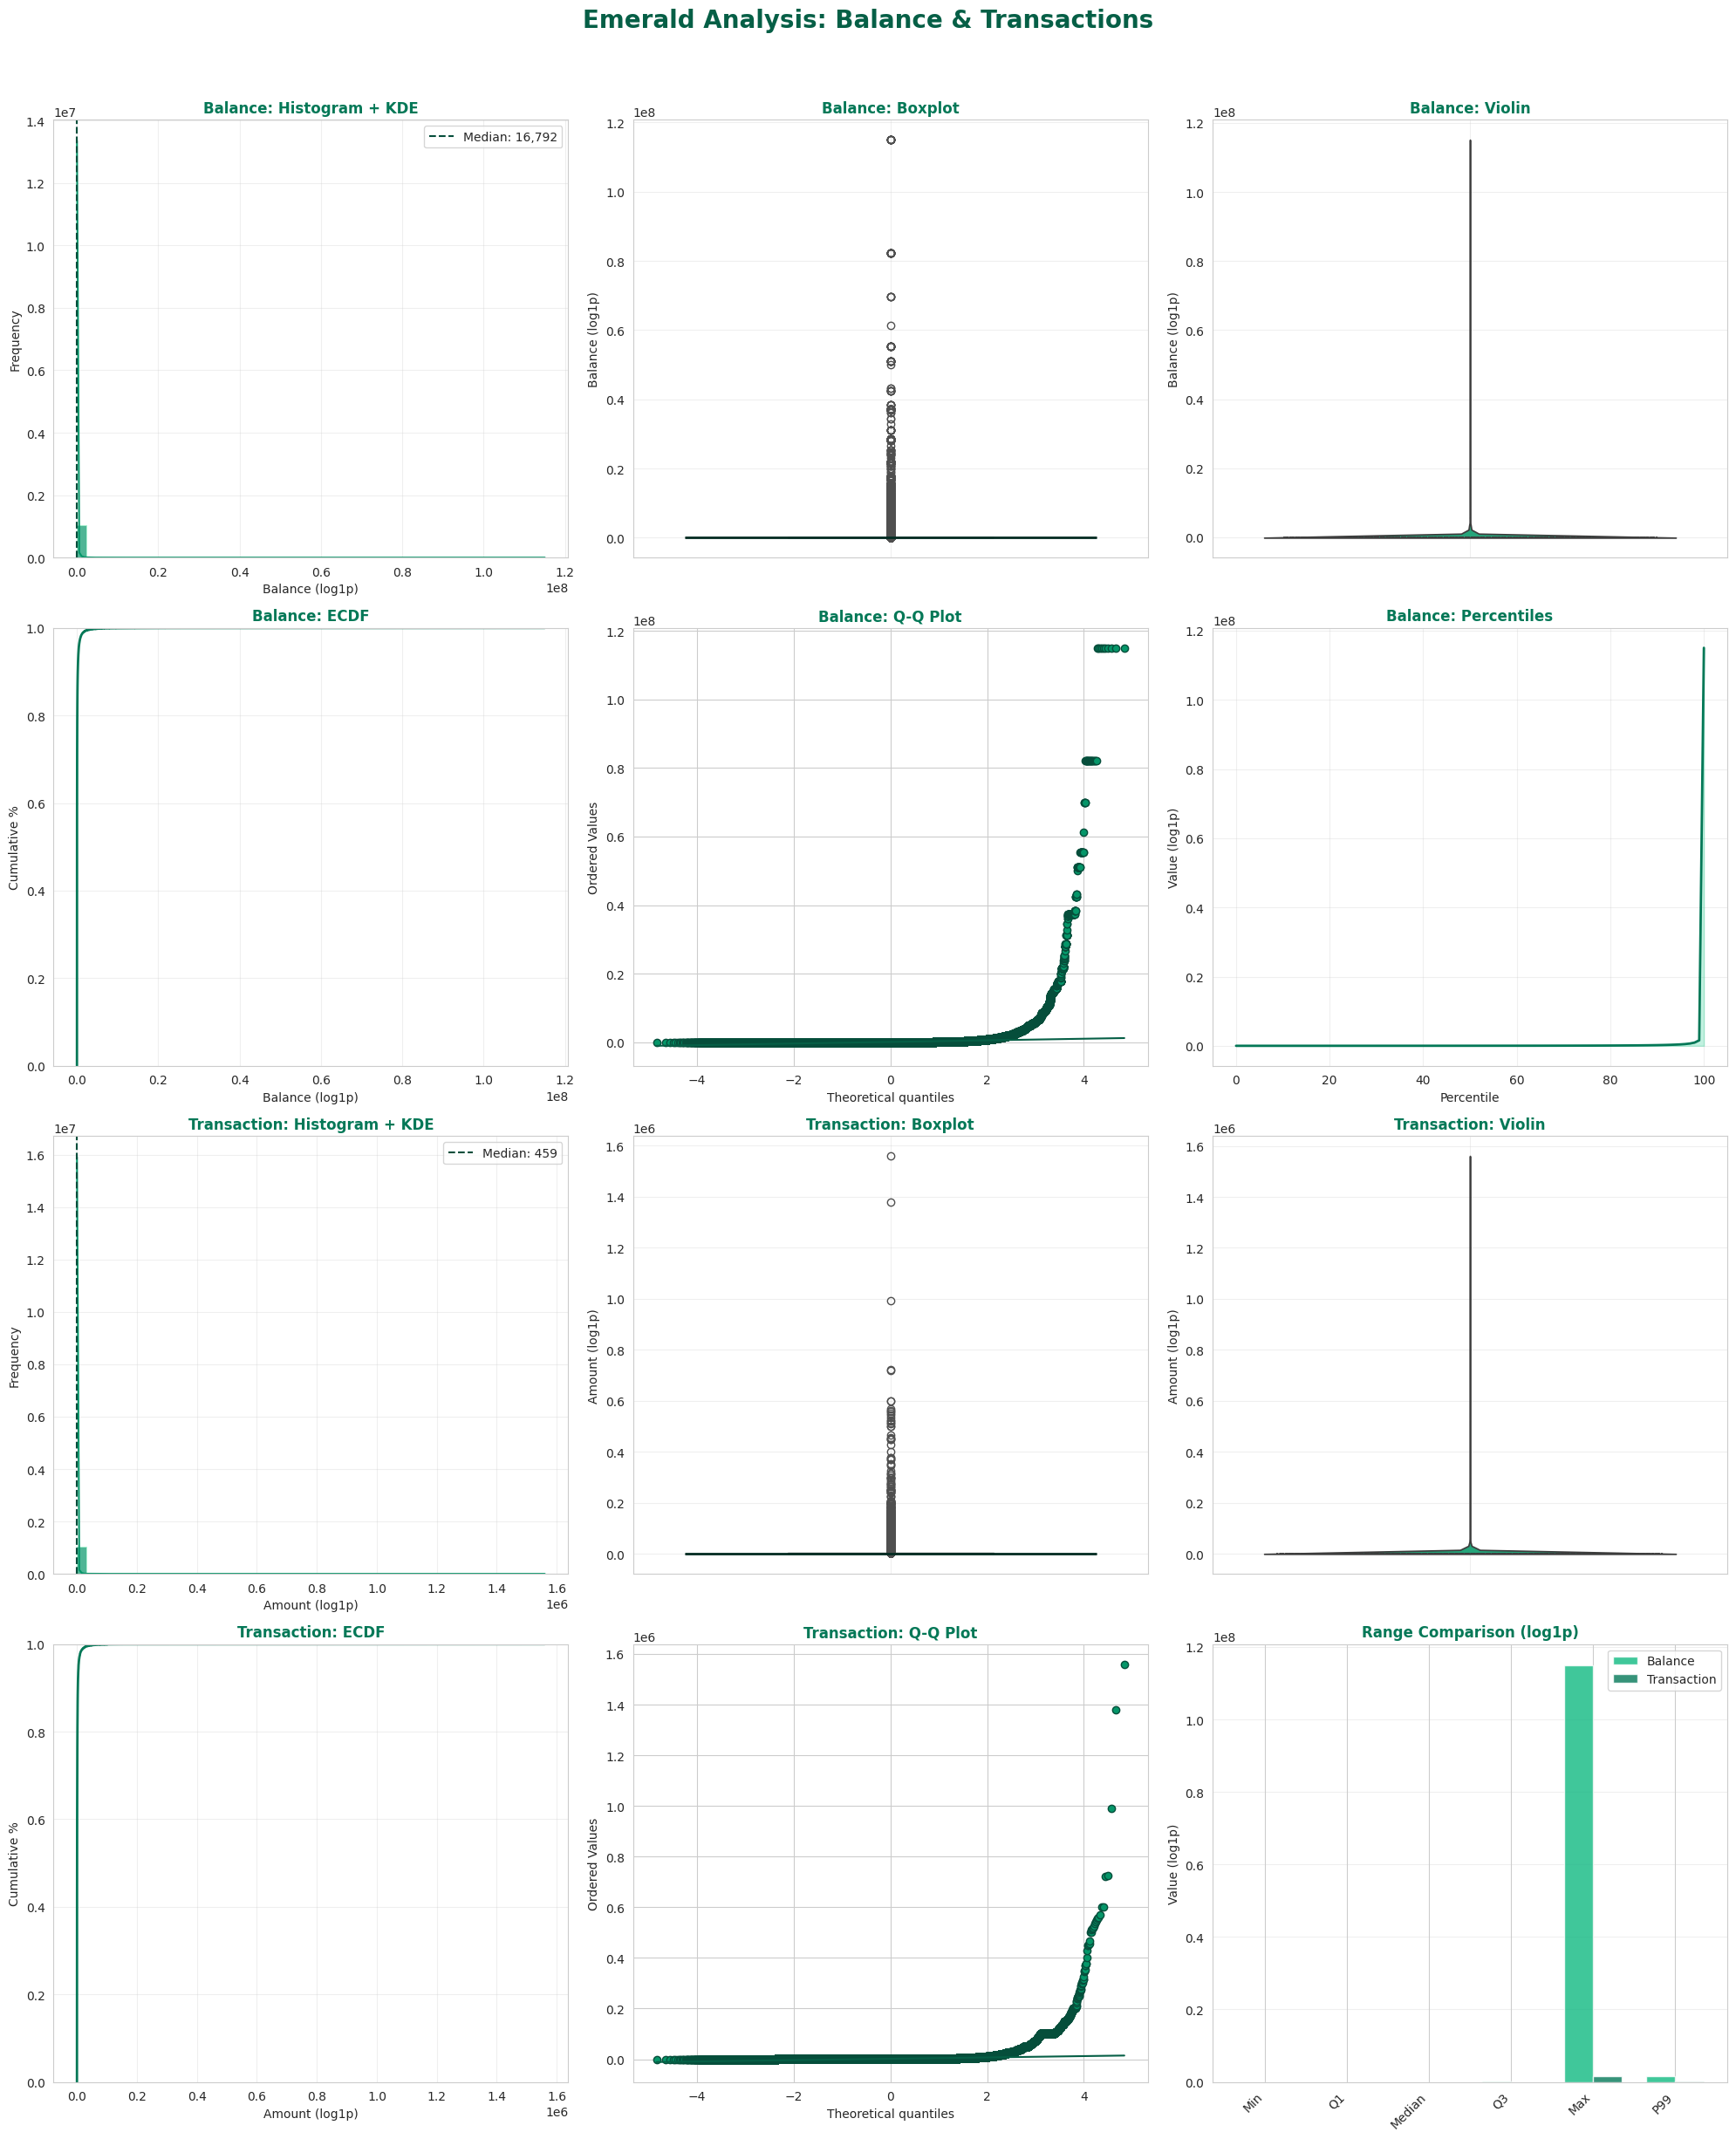


 СВОДНЫЕ МЕТРИКИ:
     Метрика        Balance  Transaction
       Count   1,048,416.00 1,048,416.00
        Mean     115,184.13     1,574.33
      Median      16,792.18       459.04
         Std     845,600.95     6,575.10
         Min           0.00         0.00
         Max 115,035,495.10 1,560,034.99
       Range 115,035,495.10 1,560,034.99
         IQR      52,732.35     1,039.00
    Skewness          60.59        47.34
    Kurtosis       5,842.17     6,641.44
         P95     415,339.18     5,200.00
         P99   1,586,508.61    20,000.00
Outliers_IQR     141,190.00   112,110.00

===================== Emerald Insights======================
 Баланс: сильная правосторонняя асимметрия (skew=60.59)
 Баланс: тяжёлые хвосты (kurtosis=5842.17) — внимание к выбросам!
 Баланс: 141,190 выбросов по IQR (13.5%)
 Транзакции: сильная правосторонняя асимметрия (skew=47.34)
 Транзакции: тяжёлые хвосты (kurtosis=6641.44) — риск экстремальных сумм
 Транзакции: 112,110 выбросов по IQR (10.7%)
 Бал

In [77]:
# изучить распределение и размах величин CustAccountBalance и TransactionAmount

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, probplot  # <--- ДОБАВИТЬ ЭТУ СТРОКУ

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

# ## Изумрудная палитра (Emerald Palette)

EMERALD = {
    '50': '#ECFDF5', '100': '#D1FAE5', '200': '#A7F3D0', '300': '#6EE7B7',
    '400': '#34D399', '500': '#10B981', '600': '#059669', '700': '#047857',
    '800': '#065F46', '900': '#064E3B', '950': '#022C22'
}

# ## Функция анализа

def analyze_column(df, col_name, title, log_transform=False):
    """Базовый анализ"""
    data = df[col_name].dropna()

    # Применяем логарифмирование для графиков
    if log_transform and (data > 0).all():
        data_plot = np.log1p(data)
        suffix = " (log1p)"
        # Статистики считаем по исходным данным для бизнес-отчётности
        data_for_stats = data
    else:
        data_plot = data
        data_for_stats = data
        suffix = ""

    # Считаем промежуточные переменные
    q1 = data_for_stats.quantile(0.25)
    q3 = data_for_stats.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers_count = len(data_for_stats[(data_for_stats < lower_bound) |
                                        (data_for_stats > upper_bound)])


    # Теперь собираем словарь
    stats_dict = {
        'Count': len(data_for_stats),
        'Mean': data_for_stats.mean(),
        'Median': data_for_stats.median(),
        'Std': data_for_stats.std(),
        'Min': data_for_stats.min(),
        'Max': data_for_stats.max(),
        'Range': data_for_stats.max() - data_for_stats.min(),
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Skewness': skew(data_for_stats),
        'Kurtosis': kurtosis(data_for_stats),
        'P95': data_for_stats.quantile(0.95),
        'P99': data_for_stats.quantile(0.99),
        'Outliers_IQR': outliers_count
    }

    print(f" {title}{suffix}")

    for k, v in stats_dict.items():
        if isinstance(v, float):
            print(f"{k:15}: {v:,.2f}")
        else:
            print(f"{k:15}: {v:,}")

    return data_plot, stats_dict

# Копируем df для безопасности
df_work = df.copy()

# Фильтрация некорректных значений (убираем отрицательные балансы и суммы)
df_work = df_work[(df_work['custAccountBalance'] >= 0) &
                  (df_work['transactionAmountInr'] >= 0)]

print(f" Обработано записей: {len(df_work):,}")


# ## Анализ custAccountBalance

balance_data, balance_stats = analyze_column(
    df_work, 'custAccountBalance', 'Баланс счёта клиента', log_transform=True
)

# ## Анализ transactionAmountInr

txn_data, txn_stats = analyze_column(
    df_work, 'transactionAmountInr', 'Сумма транзакции', log_transform=True
)

# ## Визуализация: Изумрудная галерея

fig = plt.figure(figsize=(20, 24))
fig.suptitle('Emerald Analysis: Balance & Transactions',
             fontsize=20, fontweight='bold', color=EMERALD['800'], y=1.02)

# === ГРАФИКИ БАЛАНСА ===
# 1. Гистограмма + KDE
ax1 = plt.subplot(4, 3, 1)
sns.histplot(balance_data, bins=50, kde=True, color=EMERALD['600'],
             edgecolor=EMERALD['200'], alpha=0.7)
ax1.axvline(balance_data.median(), color=EMERALD['900'], linestyle='--',
            label=f"Median: {balance_data.median():,.0f}")
ax1.set_title('Balance: Histogram + KDE', fontweight='bold', color=EMERALD['700'])
ax1.set_xlabel('Balance (log1p)'); ax1.set_ylabel('Frequency')
ax1.legend(); ax1.grid(alpha=0.3)

# 2. Boxplot
ax2 = plt.subplot(4, 3, 2)
sns.boxplot(y=balance_data, color=EMERALD['400'], boxprops=dict(alpha=0.8),
            medianprops=dict(color=EMERALD['950'], linewidth=2))
ax2.set_title('Balance: Boxplot', fontweight='bold', color=EMERALD['700'])
ax2.set_ylabel('Balance (log1p)'); ax2.grid(alpha=0.3)

# 3. Violin plot
ax3 = plt.subplot(4, 3, 3)
sns.violinplot(y=balance_data, color=EMERALD['500'], inner='quartile')
ax3.set_title('Balance: Violin', fontweight='bold', color=EMERALD['700'])
ax3.set_ylabel('Balance (log1p)'); ax3.grid(alpha=0.3)

# 4. ECDF
ax4 = plt.subplot(4, 3, 4)
sns.ecdfplot(data=balance_data, color=EMERALD['700'], linewidth=2)
ax4.set_title('Balance: ECDF', fontweight='bold', color=EMERALD['700'])
ax4.set_xlabel('Balance (log1p)'); ax4.set_ylabel('Cumulative %')
ax4.grid(alpha=0.3)

# 5. Q-Q plot (normality check)
ax5 = plt.subplot(4, 3, 5)
probplot(balance_data, dist="norm", plot=ax5)
ax5.get_lines()[0].set_markerfacecolor(EMERALD['600'])
ax5.get_lines()[0].set_markeredgecolor(EMERALD['900'])
ax5.get_lines()[1].set_color(EMERALD['800'])
ax5.set_title('Balance: Q-Q Plot', fontweight='bold', color=EMERALD['700'])

# 6. Распределение по квантилям
ax6 = plt.subplot(4, 3, 6)
quantiles = np.arange(0, 1.01, 0.01)
values = np.quantile(balance_data, quantiles)
ax6.plot(quantiles*100, values, color=EMERALD['700'], linewidth=2)
ax6.fill_between(quantiles*100, values, alpha=0.3, color=EMERALD['400'])
ax6.set_title('Balance: Percentiles', fontweight='bold', color=EMERALD['700'])
ax6.set_xlabel('Percentile'); ax6.set_ylabel('Value (log1p)')
ax6.grid(alpha=0.3)


# === ГРАФИКИ ТРАНЗАКЦИЙ ===
# 7. Гистограмма + KDE
ax7 = plt.subplot(4, 3, 7)
sns.histplot(txn_data, bins=50, kde=True, color=EMERALD['600'],
             edgecolor=EMERALD['200'], alpha=0.7)
ax7.axvline(txn_data.median(), color=EMERALD['900'], linestyle='--',
            label=f"Median: {txn_data.median():,.0f}")
ax7.set_title('Transaction: Histogram + KDE', fontweight='bold', color=EMERALD['700'])
ax7.set_xlabel('Amount (log1p)'); ax7.set_ylabel('Frequency')
ax7.legend(); ax7.grid(alpha=0.3)

# 8. Boxplot
ax8 = plt.subplot(4, 3, 8)
sns.boxplot(y=txn_data, color=EMERALD['400'], boxprops=dict(alpha=0.8),
            medianprops=dict(color=EMERALD['950'], linewidth=2))
ax8.set_title('Transaction: Boxplot', fontweight='bold', color=EMERALD['700'])
ax8.set_ylabel('Amount (log1p)'); ax8.grid(alpha=0.3)

# 9. Violin plot
ax9 = plt.subplot(4, 3, 9)
sns.violinplot(y=txn_data, color=EMERALD['500'], inner='quartile')
ax9.set_title('Transaction: Violin', fontweight='bold', color=EMERALD['700'])
ax9.set_ylabel('Amount (log1p)'); ax9.grid(alpha=0.3)

# 10. ECDF
ax10 = plt.subplot(4, 3, 10)
sns.ecdfplot(data=txn_data, color=EMERALD['700'], linewidth=2)
ax10.set_title('Transaction: ECDF', fontweight='bold', color=EMERALD['700'])
ax10.set_xlabel('Amount (log1p)'); ax10.set_ylabel('Cumulative %')
ax10.grid(alpha=0.3)

# 11. Q-Q plot
ax11 = plt.subplot(4, 3, 11)
probplot(txn_data, dist="norm", plot=ax11)
ax11.get_lines()[0].set_markerfacecolor(EMERALD['600'])
ax11.get_lines()[0].set_markeredgecolor(EMERALD['900'])
ax11.get_lines()[1].set_color(EMERALD['800'])
ax11.set_title('Transaction: Q-Q Plot', fontweight='bold', color=EMERALD['700'])

# 12. Сравнение размаха (Range Comparison)
ax12 = plt.subplot(4, 3, 12)
metrics = ['Min', 'Q1', 'Median', 'Q3', 'Max', 'P99']
balance_vals = [balance_stats[m] for m in metrics]
txn_vals = [txn_stats[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35
ax12.bar(x - width/2, balance_vals, width, label='Balance', color=EMERALD['500'], alpha=0.8)
ax12.bar(x + width/2, txn_vals, width, label='Transaction', color=EMERALD['700'], alpha=0.8)
ax12.set_title('Range Comparison (log1p)', fontweight='bold', color=EMERALD['700'])
ax12.set_xticks(x); ax12.set_xticklabels(metrics, rotation=45, ha='right')
ax12.set_ylabel('Value (log1p)'); ax12.legend(); ax12.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('emerald_analysis.png', dpi=300, bbox_inches='tight',
            facecolor=EMERALD['50'], edgecolor='none')
plt.show()


# ## Сводная таблица ключевых метрик

summary_df = pd.DataFrame({
    'Метрика': ['Count', 'Mean', 'Median', 'Std', 'Min', 'Max', 'Range',
                'IQR', 'Skewness', 'Kurtosis', 'P95', 'P99', 'Outliers_IQR'],
    'Balance': [balance_stats[k] for k in ['Count', 'Mean', 'Median', 'Std', 'Min',
                                            'Max', 'Range', 'IQR', 'Skewness',
                                            'Kurtosis', 'P95', 'P99', 'Outliers_IQR']],
    'Transaction': [txn_stats[k] for k in ['Count', 'Mean', 'Median', 'Std', 'Min',
                                           'Max', 'Range', 'IQR', 'Skewness',
                                           'Kurtosis', 'P95', 'P99', 'Outliers_IQR']]
})

pd.options.display.float_format = '{:,.2f}'.format
print("\n СВОДНЫЕ МЕТРИКИ:")
print(summary_df.to_string(index=False))


# ##  Ключевые инсайты (авто-генерация)

print(f"\n{' Emerald Insights':=^60}")

if balance_stats['Skewness'] > 1:
    print(f" Баланс: сильная правосторонняя асимметрия (skew={balance_stats['Skewness']:.2f})")
if balance_stats['Kurtosis'] > 3:
    print(f" Баланс: тяжёлые хвосты (kurtosis={balance_stats['Kurtosis']:.2f}) — внимание к выбросам!")
if balance_stats['Outliers_IQR'] > balance_stats['Count'] * 0.05:
    print(f" Баланс: {balance_stats['Outliers_IQR']:,} выбросов по IQR ({balance_stats['Outliers_IQR']/balance_stats['Count']*100:.1f}%)")

if txn_stats['Skewness'] > 1:
    print(f" Транзакции: сильная правосторонняя асимметрия (skew={txn_stats['Skewness']:.2f})")
if txn_stats['Kurtosis'] > 3:
    print(f" Транзакции: тяжёлые хвосты (kurtosis={txn_stats['Kurtosis']:.2f}) — риск экстремальных сумм")
if txn_stats['Outliers_IQR'] > txn_stats['Count'] * 0.05:
    print(f" Транзакции: {txn_stats['Outliers_IQR']:,} выбросов по IQR ({txn_stats['Outliers_IQR']/txn_stats['Count']*100:.1f}%)")

if balance_stats['Mean'] > 0 and txn_stats['Mean'] > 0:
    cv_balance = balance_stats['Std']/balance_stats['Mean']
    cv_txn = txn_stats['Std']/txn_stats['Mean']
    if cv_balance > cv_txn:
        print(f" Баланс более волатилен (CV={cv_balance:.2f}) vs транзакции (CV={cv_txn:.2f})")
    else:
        print(f" Транзакции более волатильны (CV={cv_txn:.2f}) vs баланс (CV={cv_balance:.2f})")



Распределения баланса и сумм транзакций демонстрируют экстремальную правостороннюю асимметрию (skewness 60.59 и 47.34 соответственно от нормальной симметрии) с чрезвычайно тяжёлыми хвостами (kurtosis > 5000), что указывает на наличие небольшой доли клиентов с очень высокими показателями на фоне массовой концентрации вокруг низких значений.
Разрыв между средним и медианой критический: средний баланс в 6.9 раза превышает медианный (115K у.е.  vs 16K у.е.), а средняя транзакция — в 3.4 раза (1 574 у.е. vs 459 у.е.), что свидетельствует о высокой степени неравномерности распределения финансовых показателей в клиентской базе.
Высокая доля выбросов (13.5% для баланса и 10.7% для транзакций) и экстремальная волатильность (степень «разброса» CV=7.34 для баланса) требуют применения дальнейших методов анализа и сегментации клиентов, так как классические статистические метрики (среднее, стандартное отклонение) искажены экстремальными значениями и не отражают поведение типичного клиента.

 ПРОВЕРКА ВОЗРАСТА КЛИЕНТОВ

1. Всего записей: 1,048,416
   Записей с известным DOB: 987,680
   Записей с отсутствующим DOB (флаг): 60,736

2. Статистика возраста (на момент транзакции):
   count     : 987,634.00 лет
   mean      : 31.18 лет
   std       : 8.76 лет
   min       : 0.45 лет
   25%       : 25.29 лет
   50%       : 28.95 лет
   75%       : 34.55 лет
   max       : 90.41 лет

3. Аномалии возраста: 60,782 записей (5.80%)

   Детали аномалий:
   - Отрицательный возраст (DOB > транзакции): 46
   - Возраст > 100 лет: 0


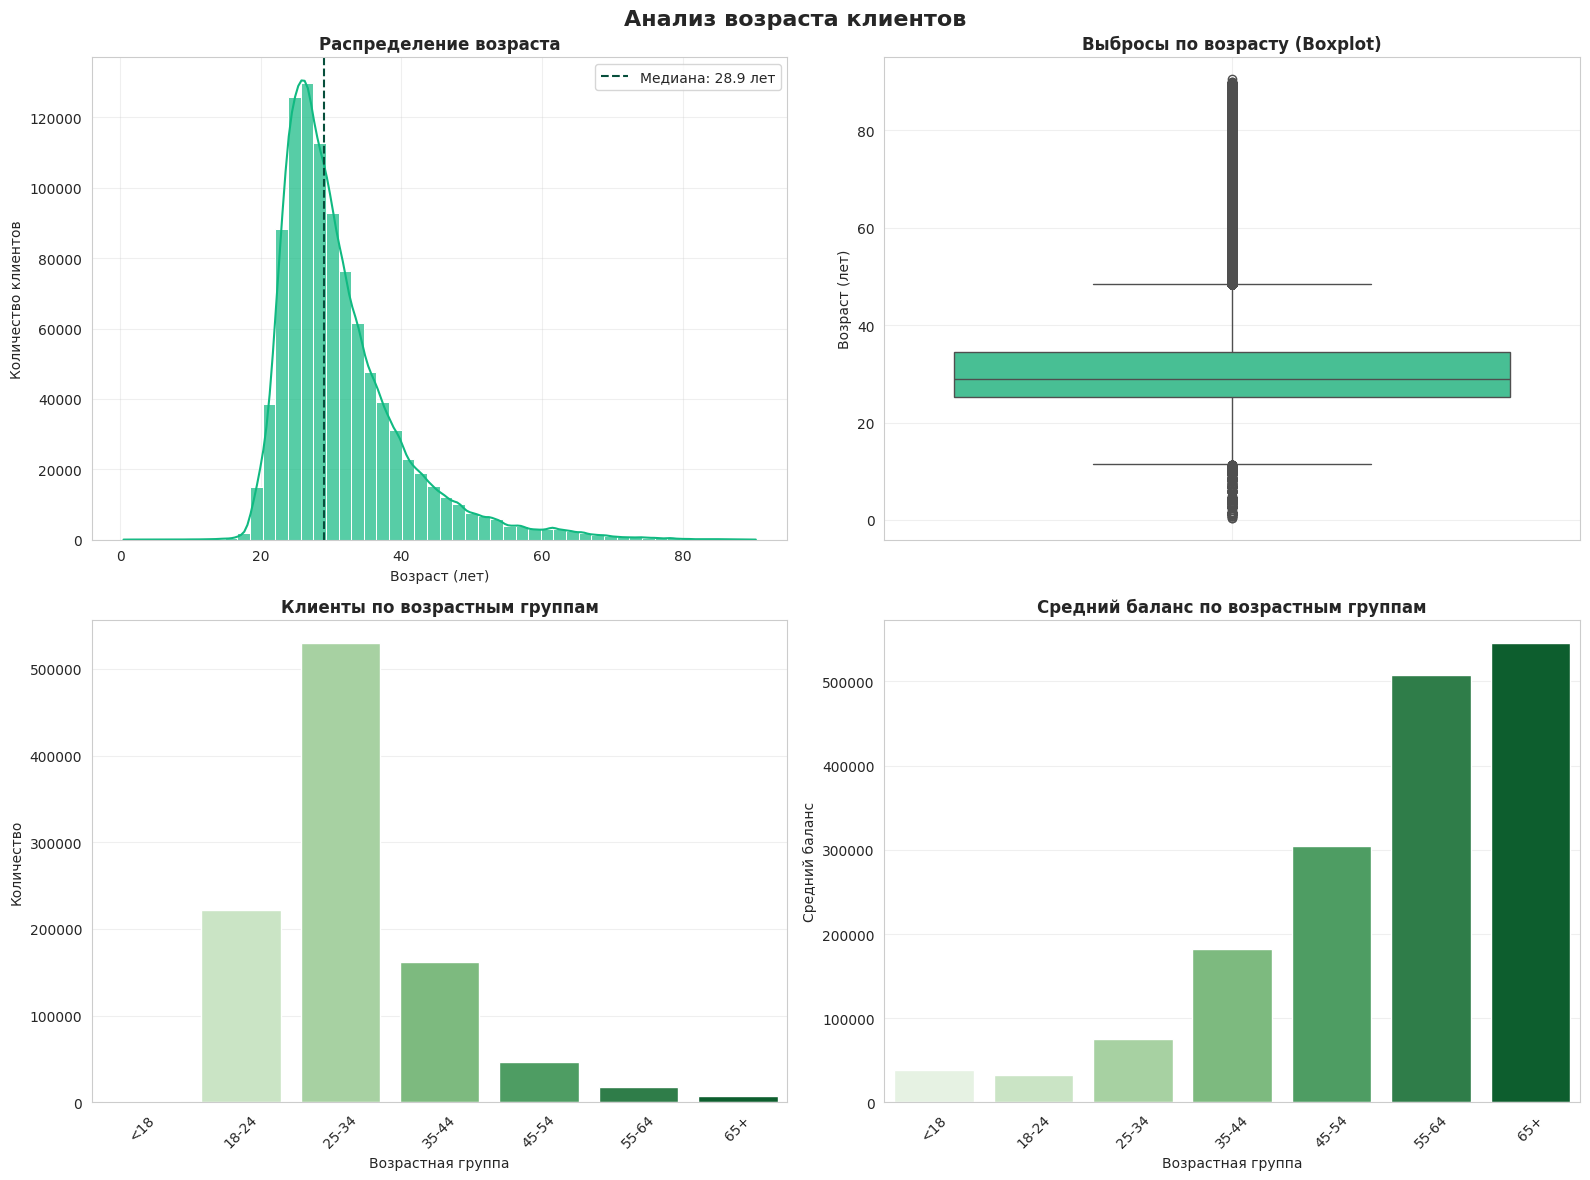

 КЛЮЧЕВЫЕ ИНСАЙТЫ ПО ВОЗРАСТУ

 Медианный возраст клиента: 28.9 лет
 Средний возраст клиента: 31.2 лет
 Самая многочисленная группа: 25-34 (529,451 клиентов)
 Доля несовершеннолетних (<18): 0.20%
 Доля клиентов 60+: 1.60%

  ВНИМАНИЕ: Обнаружены отрицательные возрасты!
   Возможно, дата рождения позже даты транзакции (ошибка в данных)

 Примеры записей с некорректным возрастом:
    customerId customerDob transactionDateTime  customerAge
16    C1376215         NaT 2016-08-01 12:47:27          NaN
22    C7018081         NaT 2016-08-03 10:47:18          NaN
28    C7935438         NaT 2016-08-03 18:36:34          NaN
35    C1211387         NaT 2016-08-03 12:59:15          NaN
151   C3334638         NaT 2016-08-09 02:49:12          NaN


In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. РАСЧЁТ ВОЗРАСТА

def calculate_age(dob, transaction_date):
    """Расчёт возраста в годах на момент транзакции"""
    if pd.isna(dob) or pd.isna(transaction_date):
        return np.nan
    age = (transaction_date - dob).days / 365.25
    return age

# Копируем данные
df_age = df.copy()

# Применяем функцию для расчёта возраста
# Векторизированный вариант быстрее, чем apply
df_age['customerAge'] = (
    (df_age['transactionDateTime'] - df_age['customerDob']).dt.days / 365.25
)

# Проверка на аномалии (отрицательный возраст или слишком старый)
# Считаем возрастом от 0 до 100 лет
valid_age_mask = (df_age['customerAge'] >= 0) & (df_age['customerAge'] <= 100)

# Помечаем некорректные записи
df_age['age_is_valid'] = valid_age_mask

# 2. СТАТИСТИКА И ПРОВЕРКИ

print(" ПРОВЕРКА ВОЗРАСТА КЛИЕНТОВ")

# Общая статистика
print(f"\n1. Всего записей: {len(df_age):,}")
print(f"   Записей с известным DOB: {df_age['customerDob'].notna().sum():,}")
print(f"   Записей с отсутствующим DOB (флаг): {df_age['isDobMissing'].sum():,}")

# Статистика по рассчитанному возрасту
print(f"\n2. Статистика возраста (на момент транзакции):")
age_stats = df_age.loc[valid_age_mask, 'customerAge'].describe()
for k, v in age_stats.items():
    print(f"   {k:10}: {v:,.2f} лет")

# Проверка аномалий
invalid_count = (~valid_age_mask).sum()
print(f"\n3. Аномалии возраста: {invalid_count:,} записей ({invalid_count/len(df_age)*100:.2f}%)")

if invalid_count > 0:
    print("\n   Детали аномалий:")
    print(f"   - Отрицательный возраст (DOB > транзакции): {((df_age['customerAge'] < 0)).sum():,}")
    print(f"   - Возраст > 100 лет: {((df_age['customerAge'] > 100)).sum():,}")

# 3. ВИЗУАЛИЗАЦИЯ

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Анализ возраста клиентов', fontsize=16, fontweight='bold')

# 1. Гистограмма возраста (только валидные данные)
ax1 = axes[0, 0]
valid_ages = df_age.loc[valid_age_mask, 'customerAge']
sns.histplot(valid_ages, bins=50, kde=True, color='#10B981', ax=ax1, alpha=0.7)
ax1.axvline(valid_ages.median(), color='#064E3B', linestyle='--',
            label=f"Медиана: {valid_ages.median():.1f} лет")
ax1.set_title('Распределение возраста', fontweight='bold')
ax1.set_xlabel('Возраст (лет)')
ax1.set_ylabel('Количество клиентов')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Boxplot
ax2 = axes[0, 1]
sns.boxplot(y=valid_ages, color='#34D399', ax=ax2)
ax2.set_title('Выбросы по возрасту (Boxplot)', fontweight='bold')
ax2.set_ylabel('Возраст (лет)')
ax2.grid(alpha=0.3)

# 3. Возрастные группы
ax3 = axes[1, 0]
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df_age['age_group'] = pd.cut(valid_ages, bins=age_bins, labels=age_labels, include_lowest=True)

age_group_counts = df_age['age_group'].value_counts().sort_index()
sns.barplot(x=age_group_counts.index, y=age_group_counts.values,
            palette='Greens', ax=ax3)
ax3.set_title('Клиенты по возрастным группам', fontweight='bold')
ax3.set_xlabel('Возрастная группа')
ax3.set_ylabel('Количество')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(alpha=0.3, axis='y')

# 4. Возраст vs Баланс (средний по группам)
ax4 = axes[1, 1]
age_balance = df_age.groupby('age_group', observed=True)['custAccountBalance'].mean()
sns.barplot(x=age_balance.index, y=age_balance.values,
            palette='Greens', ax=ax4)
ax4.set_title('Средний баланс по возрастным группам', fontweight='bold')
ax4.set_xlabel('Возрастная группа')
ax4.set_ylabel('Средний баланс')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('age_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. КЛЮЧЕВЫЕ ИНСАЙТЫ

print(" КЛЮЧЕВЫЕ ИНСАЙТЫ ПО ВОЗРАСТУ")

median_age = valid_ages.median()
mean_age = valid_ages.mean()

print(f"\n Медианный возраст клиента: {median_age:.1f} лет")
print(f" Средний возраст клиента: {mean_age:.1f} лет")

# Самая многочисленная группа
top_group = age_group_counts.idxmax()
print(f" Самая многочисленная группа: {top_group} ({age_group_counts.max():,} клиентов)")

# Доля несовершеннолетних
minor_pct = (valid_ages < 18).sum() / len(valid_ages) * 100
print(f" Доля несовершеннолетних (<18): {minor_pct:.2f}%")

# Доля пенсионеров
senior_pct = (valid_ages >= 60).sum() / len(valid_ages) * 100
print(f" Доля клиентов 60+: {senior_pct:.2f}%")

# Проверка на некорректные данные
if ((df_age['customerAge'] < 0)).sum() > 0:
    print(f"\n  ВНИМАНИЕ: Обнаружены отрицательные возрасты!")
    print(f"   Возможно, дата рождения позже даты транзакции (ошибка в данных)")

# Примеры записей с аномальным возрастом
if invalid_count > 0:
    print(f"\n Примеры записей с некорректным возрастом:")
    invalid_samples = df_age[~valid_age_mask][['customerId', 'customerDob',
                                               'transactionDateTime', 'customerAge']].head()
    print(invalid_samples.to_string())

 Расчет возраста клиентов...
 Всего записей: 1,048,416
 Пропуски DOB: 60,736 (5.8%)
 Записей с возрастом: 985,654 (94.0%)
 СТАТИСТИКА ВОЗРАСТА
Mean:                 31.2 лет
Median:               29.0 лет
Std:                   8.7
Min:                  18.0 лет
Max:                  90.4 лет
Q1 (25%):             25.3 лет
Q3 (75%):             34.6 лет
IQR:                   9.2
Skewness:             1.80
Kurtosis:             4.49
Outliers:           49,599 (5.0%)


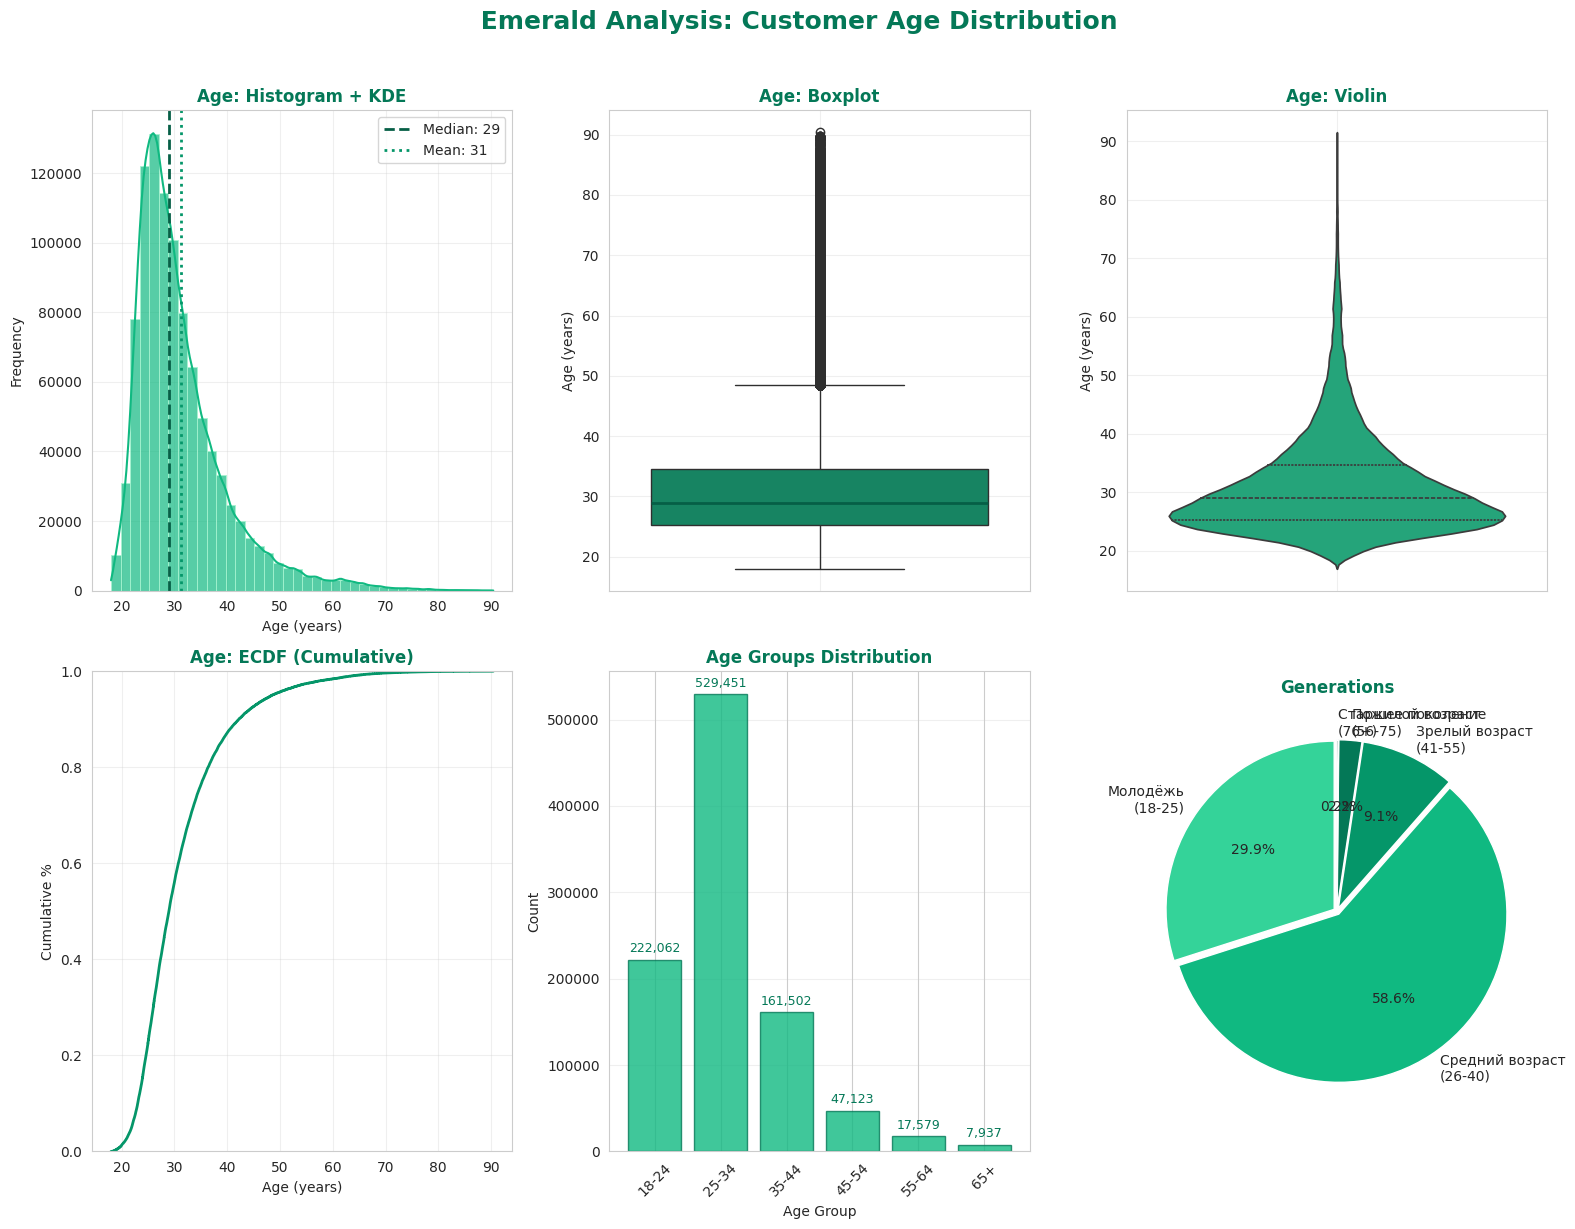

Возрастной анализ
 Доминирующая группа: 25-34 (529,451 клиентов)
 Распределение смещено вправо: Mean=31.2 vs Median=29.0
 Правосторонняя асимметрия (skewness=1.80) — больше молодых клиентов

 Поколения:
   Молодёжь
(18-25): 295,112 (29.9%)
   Средний возраст
(26-40): 577,478 (58.6%)
   Зрелый возраст
(41-55): 89,756 (9.1%)
   Пожилой возраст
(56-75): 21,799 (2.2%)
   Старшее поколение
(76+): 1,509 (0.2%)

  Выбросы по возрасту: 49,599 (5.0%)


In [49]:
# изучить возраст клиентов (визуализировать)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 10)

# Изумрудная палитра
EMERALD = ['#065F46', '#047857', '#059669', '#10B981', '#34D399', '#A7F3D0', '#ECFDF5']

# 1. ПОДГОТОВКА ДАННЫХ

print(" Расчет возраста клиентов...")

df_work = df.copy()

# Преобразуем customerDob в datetime
df_work['customerDob'] = pd.to_datetime(df_work['customerDob'], errors='coerce')

#  Возраст на дату транзакции
df_work['age_at_transaction'] = (df_work['transactionDate'] - df_work['customerDob']).dt.days / 365.25

# Текущий возраст
reference_date = pd.Timestamp('2026-02-17')  # Сегодня
df_work['age'] = (reference_date - df_work['customerDob']).dt.days / 365.25

# Фильтруем корректный возраст (18-100 лет)
df_age = df_work[(df_work['age_at_transaction'] >= 18) &
                 (df_work['age_at_transaction'] <= 100)].copy()

# Статистика пропусков
missing_dob = df['isDobMissing'].sum()
total = len(df)

print(f" Всего записей: {total:,}")
print(f" Пропуски DOB: {missing_dob:,} ({missing_dob/total*100:.1f}%)")
print(f" Записей с возрастом: {len(df_age):,} ({len(df_age)/total*100:.1f}%)")

# 2. АНАЛИЗ РАСПРЕДЕЛЕНИЯ ВОЗРАСТА

ages = df_age['age_at_transaction']

q1, q3 = ages.quantile([0.25, 0.75])
iqr = q3 - q1
outliers = len(ages[(ages < q1 - 1.5*iqr) | (ages > q3 + 1.5*iqr)])

print(" СТАТИСТИКА ВОЗРАСТА")

print(f"Mean:           {ages.mean():>10.1f} лет")
print(f"Median:         {ages.median():>10.1f} лет")
print(f"Std:            {ages.std():>10.1f}")
print(f"Min:            {ages.min():>10.1f} лет")
print(f"Max:            {ages.max():>10.1f} лет")
print(f"Q1 (25%):       {q1:>10.1f} лет")
print(f"Q3 (75%):       {q3:>10.1f} лет")
print(f"IQR:            {iqr:>10.1f}")
print(f"Skewness:       {skew(ages):>10.2f}")
print(f"Kurtosis:       {kurtosis(ages):>10.2f}")
print(f"Outliers:       {outliers:>10,} ({outliers/len(ages)*100:.1f}%)")


# 3. ВИЗУАЛИЗАЦИЯ (Изумрудная галерея)

fig = plt.figure(figsize=(16, 12))
fig.suptitle(' Emerald Analysis: Customer Age Distribution',
             fontsize=18, fontweight='bold', color=EMERALD[1], y=1.02)

# 1. Гистограмма + KDE
ax1 = plt.subplot(2, 3, 1)
sns.histplot(ages, bins=40, kde=True, color=EMERALD[3],
             edgecolor=EMERALD[5], alpha=0.7)
ax1.axvline(ages.median(), color=EMERALD[0], linestyle='--', linewidth=2,
            label=f'Median: {ages.median():.0f}')
ax1.axvline(ages.mean(), color=EMERALD[2], linestyle=':', linewidth=2,
            label=f'Mean: {ages.mean():.0f}')
ax1.set_title('Age: Histogram + KDE', fontweight='bold', color=EMERALD[1])
ax1.set_xlabel('Age (years)'); ax1.set_ylabel('Frequency')
ax1.legend(); ax1.grid(alpha=0.3)

# 2. Boxplot
ax2 = plt.subplot(2, 3, 2)
sns.boxplot(y=ages, color=EMERALD[2],
            medianprops=dict(color=EMERALD[0], linewidth=2))
ax2.set_title('Age: Boxplot', fontweight='bold', color=EMERALD[1])
ax2.set_ylabel('Age (years)'); ax2.grid(alpha=0.3)

# 3. Violin plot
ax3 = plt.subplot(2, 3, 3)
sns.violinplot(y=ages, color=EMERALD[3], inner='quartile')
ax3.set_title('Age: Violin', fontweight='bold', color=EMERALD[1])
ax3.set_ylabel('Age (years)'); ax3.grid(alpha=0.3)

# 4. ECDF
ax4 = plt.subplot(2, 3, 4)
sns.ecdfplot(data=ages, color=EMERALD[2], linewidth=2)
ax4.set_title('Age: ECDF (Cumulative)', fontweight='bold', color=EMERALD[1])
ax4.set_xlabel('Age (years)'); ax4.set_ylabel('Cumulative %')
ax4.grid(alpha=0.3)

# 5. Возрастные группы (сегментация)
ax5 = plt.subplot(2, 3, 5)
age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df_age['age_group'] = pd.cut(df_age['age_at_transaction'], bins=age_bins, labels=age_labels)

age_group_counts = df_age['age_group'].value_counts().sort_index()
bars = ax5.bar(age_labels, age_group_counts.values, color=EMERALD[3],
               edgecolor=EMERALD[1], alpha=0.8)
ax5.set_title('Age Groups Distribution', fontweight='bold', color=EMERALD[1])
ax5.set_xlabel('Age Group'); ax5.set_ylabel('Count')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(alpha=0.3, axis='y')

# Подписи на столбцах
for bar, count in zip(bars, age_group_counts.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'{count:,}', ha='center', va='bottom', fontsize=9, color=EMERALD[1])

# 6. Поколения (Generations)
ax6 = plt.subplot(2, 3, 6)
gen_bins = [18, 26, 41, 56, 76, 100]
gen_labels = ['Молодёжь\n(18-25)', 'Средний возраст\n(26-40)', 'Зрелый возраст\n(41-55)',
              'Пожилой возраст\n(56-75)', 'Старшее поколение\n(76+)']
df_age['generation'] = pd.cut(df_age['age_at_transaction'], bins=gen_bins, labels=gen_labels)

gen_counts = df_age['generation'].value_counts().sort_index()
colors_gen = [EMERALD[i] for i in [4, 3, 2, 1, 0]]
wedges, texts, autotexts = ax6.pie(gen_counts.values, labels=gen_labels,
                                    autopct='%1.1f%%', colors=colors_gen,
                                    startangle=90, explode=[0.02]*5)
ax6.set_title('Generations', fontweight='bold', color=EMERALD[1])

plt.tight_layout()
plt.savefig('emerald_age_analysis.png', dpi=300, bbox_inches='tight',
            facecolor=EMERALD[6])
plt.show()


# 4. КЛЮЧЕВЫЕ ИНСАЙТЫ


print("Возрастной анализ")

# Доминирующая группа
dominant_group = age_group_counts.idxmax()
dominant_count = age_group_counts.max()
print(f" Доминирующая группа: {dominant_group} ({dominant_count:,} клиентов)")

# Средний vs медиана
if abs(ages.mean() - ages.median()) > 2:
    print(f" Распределение {'смещено вправо' if ages.mean() > ages.median() else 'влево'}: Mean={ages.mean():.1f} vs Median={ages.median():.1f}")

# Асимметрия
sk = skew(ages)
if abs(sk) < 0.5:
    print(f" Распределение близкое к нормальному (skewness={sk:.2f})")
elif sk > 0:
    print(f" Правосторонняя асимметрия (skewness={sk:.2f}) — больше молодых клиентов")
else:
    print(f" Левосторонняя асимметрия (skewness={sk:.2f}) — больше возрастных клиентов")

# Поколения
print(f"\n Поколения:")
for gen, count in gen_counts.items():
    pct = count / len(df_age) * 100
    print(f"   {gen}: {count:,} ({pct:.1f}%)")

# Выбросы
if outliers > 0:
    print(f"\n  Выбросы по возрасту: {outliers:,} ({outliers/len(ages)*100:.1f}%)")





База клиентов сконцентрирована вокруг молодой аудитории: медианный возраст составляет 29 лет, а 88,5% клиентов — это люди до 40 лет, из которых половина (50%) находится в возрасте 25-34 лет. Такая структура создаёт стратегический риск: сегменты 45+ практически не охвачены (всего 11,5% базы), что делает бизнес уязвимым к изменениям в поведении одного поколения.

 Анализ распределения по полу...
Всего клиентов: 1,048,416

 Абсолютные значения:
   Male        :      766,208 ( 73.1%)
   Female      :      282,208 ( 26.9%)
Анализ клиентов по возрасту
 Доминирующий пол: Male (73.1%)
 Соотношение Male:Female = 2.72:1
 Мужчины: 766,208 (73.1%)
 Женщины: 282,208 (26.9%)
 Явное преобладание мужской аудитории


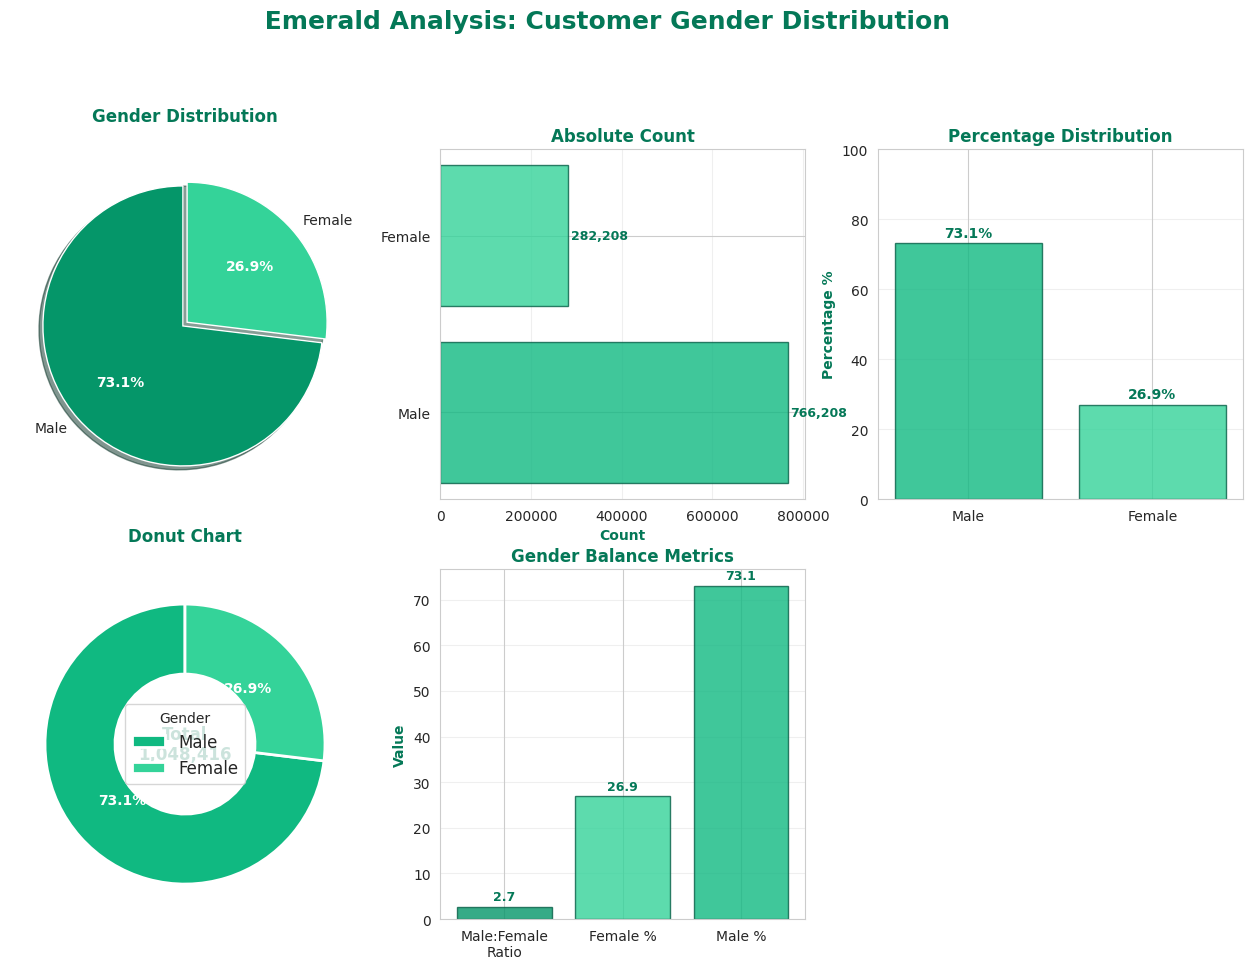

In [79]:
# изучить пол клиентов (визуализировать)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройки
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 10)

# Изумрудная палитра
EMERALD = ['#065F46', '#047857', '#059669', '#10B981', '#34D399', '#A7F3D0', '#ECFDF5']


# 1. ПОДГОТОВКА ДАННЫХ

print(" Анализ распределения по полу...")

df_work = df.copy()
# Словарь для нормализации значений пола
gender_map = {
    'M': 'Male', 'm': 'Male', 'Male': 'Male', 'MALE': 'Male', 'male': 'Male',
    'F': 'Female', 'f': 'Female', 'Female': 'Female', 'FEMALE': 'Female', 'female': 'Female',
    'U': 'Unknown', 'u': 'Unknown', 'Unknown': 'Unknown', '': 'Unknown', ' ': 'Unknown'
}

df_work['custGender'] = df_work['custGender'].map(lambda x: gender_map.get(str(x).strip(), x))

# Статистика
total = len(df_work)
gender_counts = df_work['custGender'].value_counts()
gender_pct = df_work['custGender'].value_counts(normalize=True) * 100

print(f"Всего клиентов: {total:,}")
print(f"\n Абсолютные значения:")
for gender, count in gender_counts.items():
    print(f"   {gender:12}: {count:>12,} ({count/total*100:>5.1f}%)")

# 2. ВИЗУАЛИЗАЦИЯ

fig = plt.figure(figsize=(16, 10))
fig.suptitle(' Emerald Analysis: Customer Gender Distribution',
             fontsize=18, fontweight='bold', color=EMERALD[1], y=1.02)

# 1. Круговая диаграмма (основная)
ax1 = plt.subplot(2, 3, 1)
colors_pie = [EMERALD[i] for i in [2, 4, 1, 5, 0]]  # Разные оттенки для категорий
wedges, texts, autotexts = ax1.pie(gender_counts.values,
                                    labels=gender_counts.index,
                                    autopct='%1.1f%%',
                                    colors=colors_pie[:len(gender_counts)],
                                    startangle=90,
                                    explode=[0.02]*len(gender_counts),
                                    shadow=True)
# Улучшаем читаемость процентов
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)
ax1.set_title('Gender Distribution', fontweight='bold', color=EMERALD[1], pad=20)

# 2. Горизонтальный bar chart
ax2 = plt.subplot(2, 3, 2)
bars = ax2.barh(gender_counts.index, gender_counts.values,
                color=[EMERALD[i] for i in [3, 4, 2, 1, 0]][:len(gender_counts)],
                edgecolor=EMERALD[0], alpha=0.8)
ax2.set_xlabel('Count', fontweight='bold', color=EMERALD[1])
ax2.set_title('Absolute Count', fontweight='bold', color=EMERALD[1])
ax2.grid(alpha=0.3, axis='x')

# Подписи на столбцах
for bar, count in zip(bars, gender_counts.values):
    ax2.text(bar.get_width() + total*0.005, bar.get_y() + bar.get_height()/2,
             f'{count:,}', va='center', fontsize=9, color=EMERALD[1], fontweight='bold')

# 3. Процентное соотношение
ax3 = plt.subplot(2, 3, 3)
bars_pct = ax3.bar(gender_pct.index, gender_pct.values,
                   color=[EMERALD[i] for i in [3, 4, 2, 1, 0]][:len(gender_pct)],
                   edgecolor=EMERALD[0], alpha=0.8)
ax3.set_ylabel('Percentage %', fontweight='bold', color=EMERALD[1])
ax3.set_title('Percentage Distribution', fontweight='bold', color=EMERALD[1])
ax3.set_ylim([0, 100])
ax3.grid(alpha=0.3, axis='y')

# Подписи процентов
for bar, pct in zip(bars_pct, gender_pct.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{pct:.1f}%', ha='center', va='bottom',
             fontsize=10, color=EMERALD[1], fontweight='bold')

# 4. Donut chart (схема кольца)
ax4 = plt.subplot(2, 3, 4)
wedges, texts, autotexts = ax4.pie(gender_counts.values,
                                    labels=None,
                                    autopct='%1.1f%%',
                                    colors=[EMERALD[i] for i in [3, 4, 2, 1, 0]][:len(gender_counts)],
                                    startangle=90,
                                    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2))

# Улучшаем читаемость процентов
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# Добавляем легенду и центральный текст
ax4.legend(gender_counts.index, loc='center', fontsize=12,
           bbox_to_anchor=(0.5, 0.5), title='Gender')
ax4.text(0, 0, f'Total\n{total:,}', ha='center', va='center',
         fontsize=12, fontweight='bold', color=EMERALD[1])
ax4.set_title('Donut Chart', fontweight='bold', color=EMERALD[1], pad=20)

# 5. Гендерный баланс (соотношение)
ax5 = plt.subplot(2, 3, 5)
if len(gender_counts) >= 2:
    male_count = gender_counts.get('Male', 0)
    female_count = gender_counts.get('Female', 0)
    if female_count > 0:
        ratio = male_count / female_count
    else:
        ratio = 0

    categories = ['Male:Female\nRatio', 'Female %', 'Male %']
    values = [ratio, female_count/total*100, male_count/total*100]
    colors_bar = [EMERALD[2], EMERALD[4], EMERALD[3]]

    bars = ax5.bar(categories, values, color=colors_bar, edgecolor=EMERALD[0], alpha=0.8)
    ax5.set_ylabel('Value', fontweight='bold', color=EMERALD[1])
    ax5.set_title('Gender Balance Metrics', fontweight='bold', color=EMERALD[1])
    ax5.grid(alpha=0.3, axis='y')

    for bar, val in zip(bars, values):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                 f'{val:.1f}' if val > 1 else f'{val:.2f}',
                 ha='center', va='bottom', fontsize=9, color=EMERALD[1], fontweight='bold')
else:
    ax5.text(0.5, 0.5, 'Insufficient\ndata', ha='center', va='center',
             fontsize=12, color=EMERALD[1])
    ax5.set_title('Gender Balance Metrics', fontweight='bold', color=EMERALD[1])

# 3. КЛЮЧЕВЫЕ ИНСАЙТЫ

print("Анализ клиентов по возрасту")

# Доминирующий пол
dominant_gender = gender_counts.idxmax()
dominant_pct = gender_pct.max()
print(f" Доминирующий пол: {dominant_gender} ({dominant_pct:.1f}%)")

# Гендерный баланс
if len(gender_counts) >= 2:
    male = gender_counts.get('Male', 0)
    female = gender_counts.get('Female', 0)
    total_mf = male + female

    if total_mf > 0:
        male_pct = male / total_mf * 100
        female_pct = female / total_mf * 100
        ratio = male / female if female > 0 else float('inf')

        print(f" Соотношение Male:Female = {ratio:.2f}:1")
        print(f" Мужчины: {male:,} ({male_pct:.1f}%)")
        print(f" Женщины: {female:,} ({female_pct:.1f}%)")

        if abs(male_pct - 50) < 5:
            print(f" Гендерный баланс близок к равномерному")
        elif male_pct > 60:
            print(f" Явное преобладание мужской аудитории")
        elif female_pct > 60:
            print(f" Явное преобладание женской аудитории")




Клиентская база демонстрирует гендерный дисбаланс: мужчины составляют большинство клиентов банка — 73.1% (766 208 человек), в то время как женщины представлены значительно меньше — 26.9% (282 208 человек). Соотношение мужчин к женщинам составляет 2.7:1, что указывает на сильную ориентацию банка на мужскую аудиторию и наличие барьеров для привлечения женской аудитории.

 СТАТИСТИКА ПО ЛОКАЦИЯМ
Всего записей: 1,048,416
Уникальных локаций: 9355

Топ-10 локаций по количеству клиентов:
№   Локация                  Клиентов     Доля
--------------------------------------------------
1   MUMBAI                    103,595     9.9%
2   NEW DELHI                  84,928     8.1%
3   BANGALORE                  81,555     7.8%
4   GURGAON                    73,818     7.0%
5   DELHI                      71,019     6.8%
6   NOIDA                      32,784     3.1%
7   CHENNAI                    30,009     2.9%
8   PUNE                       25,851     2.5%
9   HYDERABAD                  23,049     2.2%
10  THANE                      21,505     2.1%

 Концентрация:
   Топ-5 локаций: 39.6% всех клиентов
   Топ-10 локаций: 52.3% всех клиентов


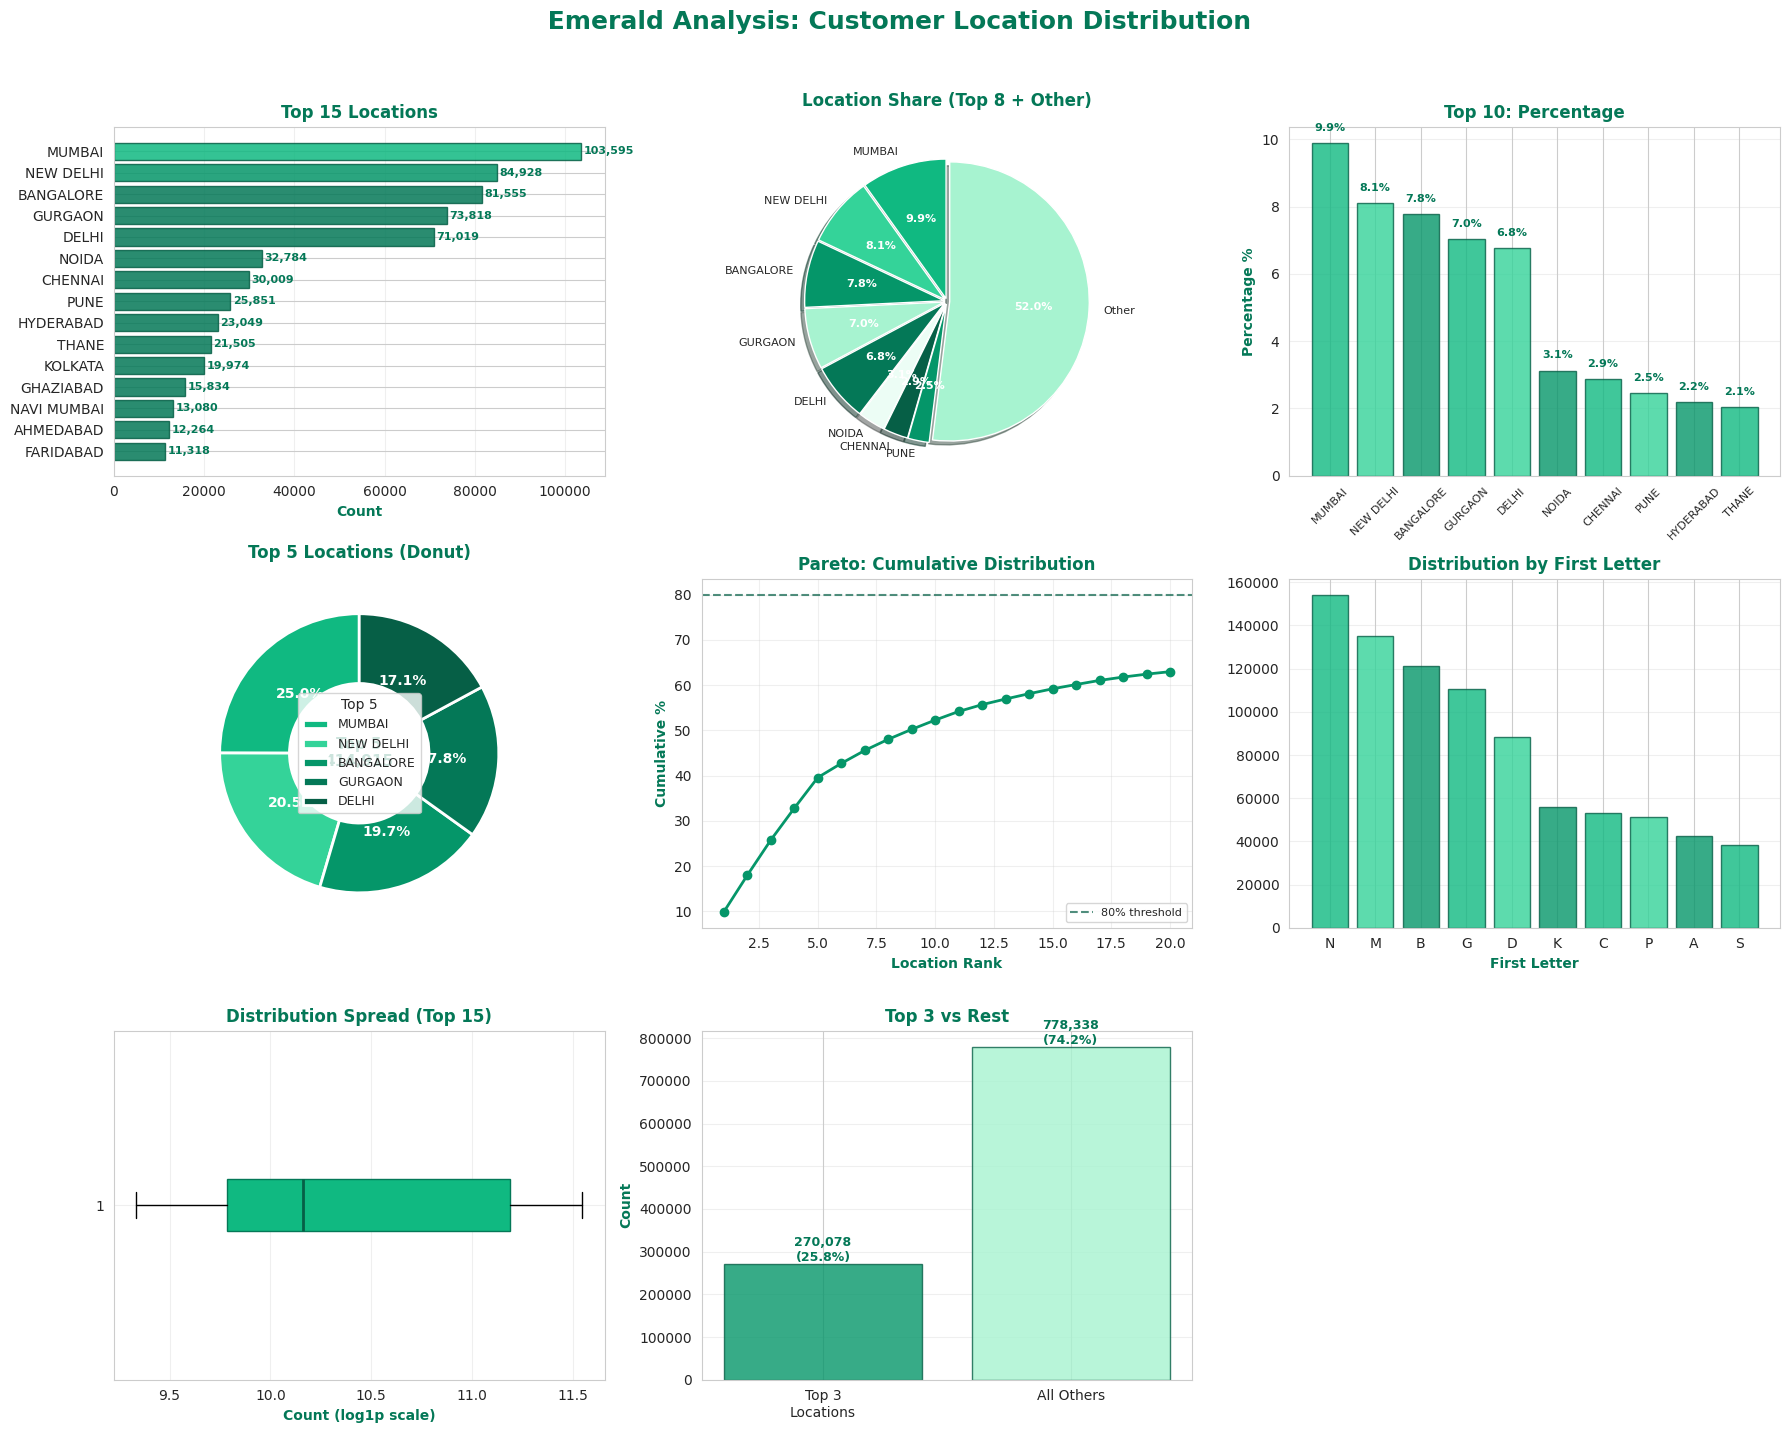

 Анализ локации клиентов
 Лидер: MUMBAI — 103,595 клиентов (9.9%)
 Умеренная концентрация: топ-5 локаций = 39.6% базы
 Выраженный «длинный хвост»: 9261 локаций с долей <0.1%


In [80]:
# изучить место жительства клиентов (визуализировать)

# Статистика
total = len(df_work)
unique_locations = df_work['custLocation'].nunique()
location_counts = df_work['custLocation'].value_counts()
location_pct = df_work['custLocation'].value_counts(normalize=True) * 100


print(" СТАТИСТИКА ПО ЛОКАЦИЯМ")

print(f"Всего записей: {total:,}")
print(f"Уникальных локаций: {unique_locations}")
print(f"\nТоп-10 локаций по количеству клиентов:")
print(f"{'№':<3} {'Локация':<20} {'Клиентов':>12} {'Доля':>8}")
print(f"{'-'*50}")

for i, (loc, count) in enumerate(location_counts.head(10).items(), 1):
    pct = count / total * 100
    print(f"{i:<3} {loc:<20} {count:>12,} {pct:>7.1f}%")

# Доля топ-5 и топ-10
top5_share = location_counts.head(5).sum() / total * 100
top10_share = location_counts.head(10).sum() / total * 100
print(f"\n Концентрация:")
print(f"   Топ-5 локаций: {top5_share:.1f}% всех клиентов")
print(f"   Топ-10 локаций: {top10_share:.1f}% всех клиентов")


# 2. ВИЗУАЛИЗАЦИЯ

fig = plt.figure(figsize=(18, 14))
fig.suptitle(' Emerald Analysis: Customer Location Distribution',
             fontsize=18, fontweight='bold', color=EMERALD[1], y=1.02)

# 1. Горизонтальный bar chart (Топ-15 локаций)
ax1 = plt.subplot(3, 3, 1)
top_n = 15
top_locs = location_counts.head(top_n)
colors_bar = [EMERALD[3 - min(i, 2)] for i in range(len(top_locs))]  # Градиент

bars = ax1.barh(top_locs.index[::-1], top_locs.values[::-1],
                color=colors_bar[::-1], edgecolor=EMERALD[0], alpha=0.85)
ax1.set_xlabel('Count', fontweight='bold', color=EMERALD[1])
ax1.set_title('Top 15 Locations', fontweight='bold', color=EMERALD[1])
ax1.grid(alpha=0.3, axis='x')

# Подписи на столбцах
for bar, count in zip(bars, top_locs.values[::-1]):
    ax1.text(bar.get_width() + total*0.0005, bar.get_y() + bar.get_height()/2,
             f'{count:,}', va='center', fontsize=8, color=EMERALD[1], fontweight='bold')

# 2. Круговая диаграмма (Топ-8 + Other)
ax2 = plt.subplot(3, 3, 2)
top8 = location_counts.head(8)
other_count = location_counts.iloc[8:].sum()
labels_pie = list(top8.index) + ['Other']
sizes_pie = list(top8.values) + [other_count]
colors_pie = [EMERALD[i] for i in [3, 4, 2, 5, 1, 6, 0, 2, 5]]

wedges, texts, autotexts = ax2.pie(sizes_pie, labels=labels_pie, autopct='%1.1f%%',
                                    colors=colors_pie[:len(labels_pie)],
                                    startangle=90, explode=[0.02]*len(labels_pie),
                                    shadow=True, textprops={'fontsize': 8})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax2.set_title('Location Share (Top 8 + Other)', fontweight='bold', color=EMERALD[1], pad=15)

# 3. Процентное распределение (Топ-10)
ax3 = plt.subplot(3, 3, 3)
top10_pct = location_pct.head(10)
bars_pct = ax3.bar(top10_pct.index, top10_pct.values,
                   color=[EMERALD[3], EMERALD[4], EMERALD[2]]*4,
                   edgecolor=EMERALD[0], alpha=0.8)
ax3.set_ylabel('Percentage %', fontweight='bold', color=EMERALD[1])
ax3.set_title('Top 10: Percentage', fontweight='bold', color=EMERALD[1])
ax3.tick_params(axis='x', rotation=45, labelsize=8)
ax3.grid(alpha=0.3, axis='y')

for bar, pct in zip(bars_pct, top10_pct.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=8, color=EMERALD[1], fontweight='bold')

# 4. Donut chart (Топ-5)
ax4 = plt.subplot(3, 3, 4)
top5 = location_counts.head(5)
wedges, texts, autotexts = ax4.pie(top5.values, labels=None,
                                    autopct='%1.1f%%',
                                    colors=[EMERALD[i] for i in [3, 4, 2, 1, 0]],
                                    startangle=90,
                                    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax4.legend(top5.index, loc='center', fontsize=9, bbox_to_anchor=(0.5, 0.5), title='Top 5')
ax4.text(0, 0, f'Top 5\n{top5.sum():,}', ha='center', va='center',
         fontsize=11, fontweight='bold', color=EMERALD[1])
ax4.set_title('Top 5 Locations (Donut)', fontweight='bold', color=EMERALD[1], pad=15)

# 5. Кумулятивное распределение (Pareto)
ax5 = plt.subplot(3, 3, 5)
cumulative_pct = location_counts.head(20).cumsum() / total * 100
ax5.plot(range(1, 21), cumulative_pct.values, marker='o', color=EMERALD[2], linewidth=2)
ax5.axhline(y=80, color=EMERALD[0], linestyle='--', label='80% threshold', alpha=0.7)
ax5.set_xlabel('Location Rank', fontweight='bold', color=EMERALD[1])
ax5.set_ylabel('Cumulative %', fontweight='bold', color=EMERALD[1])
ax5.set_title('Pareto: Cumulative Distribution', fontweight='bold', color=EMERALD[1])
ax5.grid(alpha=0.3)
ax5.legend(fontsize=8)

# 6. Heatmap-style: концентрация по первым буквам
ax6 = plt.subplot(3, 3, 6)
first_letters = df_work['custLocation'].str[0].str.upper().value_counts().head(10)
bars_letter = ax6.bar(first_letters.index, first_letters.values,
                      color=[EMERALD[3], EMERALD[4], EMERALD[2]]*4,
                      edgecolor=EMERALD[0], alpha=0.8)
ax6.set_xlabel('First Letter', fontweight='bold', color=EMERALD[1])
ax6.set_title('Distribution by First Letter', fontweight='bold', color=EMERALD[1])
ax6.grid(alpha=0.3, axis='y')

# 7. Boxplot: клиенты по локациям (логарифмическая шкала)
ax7 = plt.subplot(3, 3, 7)
top15_counts = location_counts.head(15)
ax7.boxplot([np.log1p(top15_counts.values)], vert=False, patch_artist=True,
            boxprops=dict(facecolor=EMERALD[3], color=EMERALD[1]),
            medianprops=dict(color=EMERALD[0], linewidth=2))
ax7.set_xlabel('Count (log1p scale)', fontweight='bold', color=EMERALD[1])
ax7.set_title('Distribution Spread (Top 15)', fontweight='bold', color=EMERALD[1])
ax7.grid(alpha=0.3)

# 8. Сравнение: топ-3 vs остальные
ax8 = plt.subplot(3, 3, 8)
top3_sum = location_counts.head(3).sum()
rest_sum = location_counts.iloc[3:].sum()
categories = ['Top 3\nLocations', 'All Others']
values = [top3_sum, rest_sum]
colors_comp = [EMERALD[2], EMERALD[5]]

bars_comp = ax8.bar(categories, values, color=colors_comp, edgecolor=EMERALD[0], alpha=0.8)
ax8.set_ylabel('Count', fontweight='bold', color=EMERALD[1])
ax8.set_title('Top 3 vs Rest', fontweight='bold', color=EMERALD[1])
ax8.grid(alpha=0.3, axis='y')

for bar, val in zip(bars_comp, values):
    pct = val / total * 100
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.001,
             f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
             fontsize=9, color=EMERALD[1], fontweight='bold')

plt.tight_layout()
plt.savefig('emerald_location_analysis.png', dpi=300, bbox_inches='tight',
            facecolor=EMERALD[6])
plt.show()


# 3. АНАЛИЗ ЛОКАЦИИ КЛИЕНТОВ


print(" Анализ локации клиентов")


# Топ-локация
top_loc = location_counts.index[0]
top_loc_count = location_counts.iloc[0]
top_loc_pct = location_pct.iloc[0]
print(f" Лидер: {top_loc} — {top_loc_count:,} клиентов ({top_loc_pct:.1f}%)")

# Концентрация
if top5_share > 50:
    print(f" Высокая концентрация: топ-5 локаций = {top5_share:.1f}% базы")
elif top5_share > 30:
    print(f" Умеренная концентрация: топ-5 локаций = {top5_share:.1f}% базы")
else:
    print(f" Распределённая база: топ-5 локаций = {top5_share:.1f}% базы")

# Длинный хвост
long_tail = (location_pct < 0.1).sum()
if long_tail > unique_locations * 0.5:
    print(f" Выраженный «длинный хвост»: {long_tail} локаций с долей <0.1%")


Клиентская база охватывает всю Индию. Крупнейшие мегаполисы - это топ-5-ти локаций (Mumbai, New Delhi, Bangalore, Gurgaon, Delhi) аккумулируют 25.8% всех клиентов, при этом Mumbai лидирует с 103 595 клиентами (9.9%).  Топ-3 города удерживают лишь четверть базы, а 52% клиентов распределены по множеству других локаций («Other»), что свидетельствует о широком географическом охвате и региональной стратегии банка. Это снижает риски зависимости от отдельных рынков и обеспечивает устойчивость клиентской базы.

 Анализ динамики транзакций...
 ВРЕМЕННАЯ СТАТИСТИКА
Период: 2016-08-01 — 2016-10-21
Всего дней: 55
Всего транзакций: 1,048,416
Среднее в день: 19,062

 Топ-5 дней по активности:
   2016-08-07: 27,254 транзакций
   2016-08-13: 26,912 транзакций
   2016-08-06: 26,578 транзакций
   2016-09-04: 26,560 транзакций
   2016-09-03: 26,421 транзакций


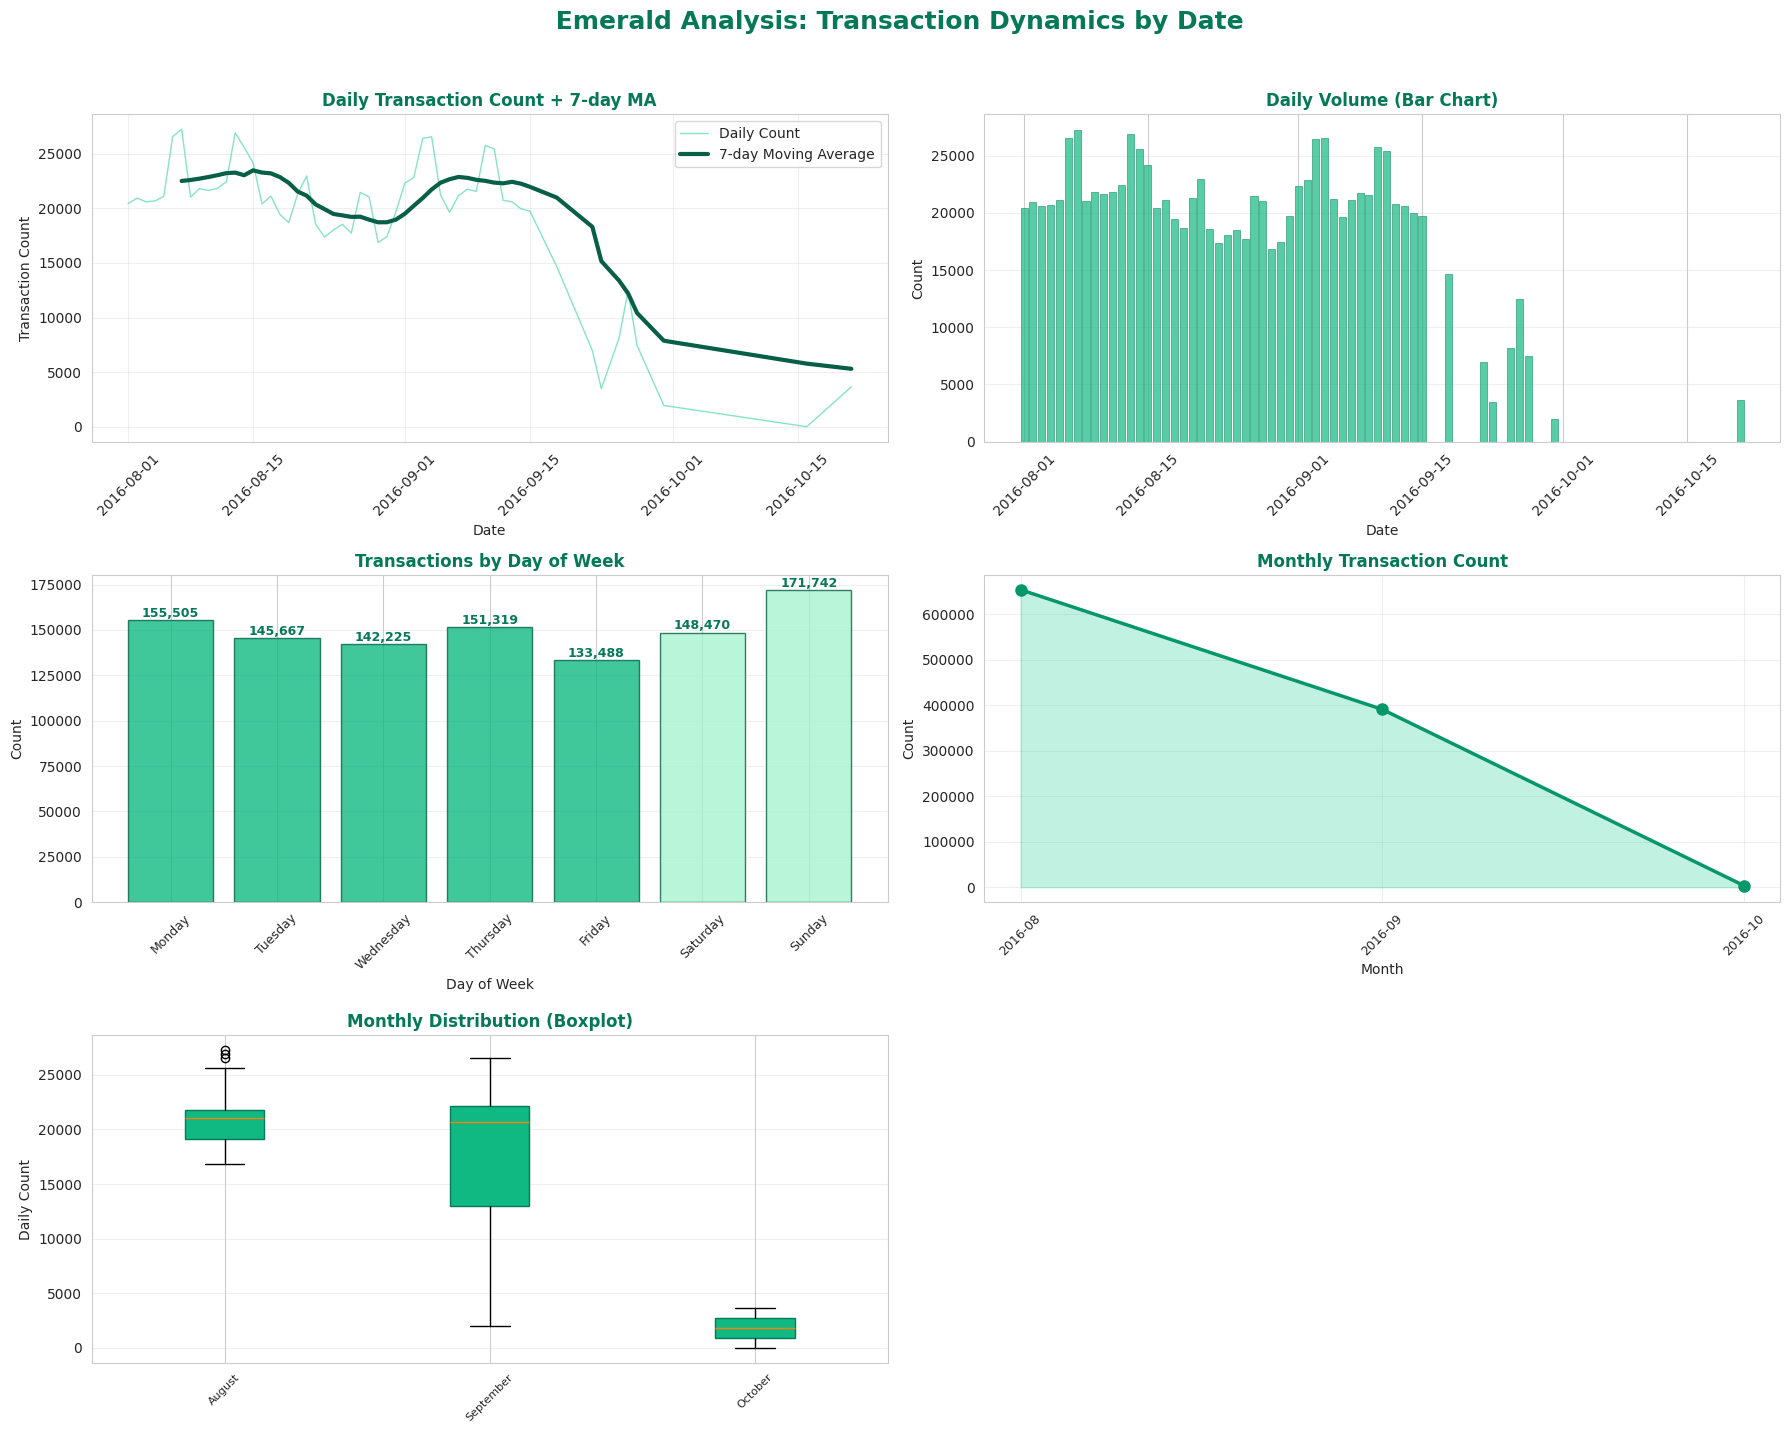

 ДИНАМИКА ТРАНЗАКЦИЙ
 Пик активности: 2016-08-07 (27,254 транзакций)
 Минимум: 2016-10-16 (3 транзакций)
 Лучший день недели: Sunday (171,742 транзакций)
 Самый тихий день: Friday (133,488 транзакций)
 Спад активности: -22.5% (вторая половина периода)
 Высокая волатильность: CV=0.34 (неравномерная нагрузка)


In [82]:
# посмотреть динамику транзакций по дате (в кол-ве TransactionID)

# 1. ПОДГОТОВКА ДАННЫХ

print(" Анализ динамики транзакций...")

# Извлекаем дату (без времени)
df_work['transactionDate'] = df_work['transactionDateTime'].dt.date

# Агрегация по датам
daily_txn = df_work.groupby('transactionDate').agg({
    'transactionId': 'count',
    'transactionAmountInr': ['sum', 'mean']
}).round(2)

daily_txn.columns = ['txn_count', 'total_amount', 'avg_amount']
daily_txn = daily_txn.reset_index()
daily_txn['transactionDate'] = pd.to_datetime(daily_txn['transactionDate'])

# Скользящее среднее (7 дней)
daily_txn['rolling_7d'] = daily_txn['txn_count'].rolling(window=7).mean()

# Статистика
total_days = len(daily_txn)
total_txn = len(df_work)
avg_daily_txn = total_txn / total_days
period_start = daily_txn['transactionDate'].min()
period_end = daily_txn['transactionDate'].max()


print(" ВРЕМЕННАЯ СТАТИСТИКА")

print(f"Период: {period_start.date()} — {period_end.date()}")
print(f"Всего дней: {total_days}")
print(f"Всего транзакций: {total_txn:,}")
print(f"Среднее в день: {avg_daily_txn:,.0f}")
print(f"\n Топ-5 дней по активности:")
top5_days = daily_txn.nlargest(5, 'txn_count')
for i, row in top5_days.iterrows():
    print(f"   {row['transactionDate'].date()}: {row['txn_count']:,.0f} транзакций")

# 2. ВИЗУАЛИЗАЦИЯ

fig = plt.figure(figsize=(18, 14))
fig.suptitle(' Emerald Analysis: Transaction Dynamics by Date',
             fontsize=18, fontweight='bold', color=EMERALD[1], y=1.02)

# 1. Основная динамика (линия + скользящее среднее)
ax1 = plt.subplot(3, 2, 1)
ax1.plot(daily_txn['transactionDate'], daily_txn['txn_count'],
         color=EMERALD[4], linewidth=1, alpha=0.6, label='Daily Count')
ax1.plot(daily_txn['transactionDate'], daily_txn['rolling_7d'],
         color=EMERALD[0], linewidth=3, label='7-day Moving Average')
ax1.set_title('Daily Transaction Count + 7-day MA', fontweight='bold', color=EMERALD[1], fontsize=12)
ax1.set_xlabel('Date'); ax1.set_ylabel('Transaction Count')
ax1.legend(loc='upper right'); ax1.grid(alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Столбчатая диаграмма по дням
ax2 = plt.subplot(3, 2, 2)
ax2.bar(daily_txn['transactionDate'], daily_txn['txn_count'],
        color=EMERALD[3], edgecolor=EMERALD[1], alpha=0.7, linewidth=0.5)
ax2.set_title('Daily Volume (Bar Chart)', fontweight='bold', color=EMERALD[1], fontsize=12)
ax2.set_xlabel('Date'); ax2.set_ylabel('Count')
ax2.grid(alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

# 3. Распределение по дням недели
ax3 = plt.subplot(3, 2, 3)
df_work['dayofweek'] = df_work['transactionDateTime'].dt.dayofweek
df_work['dayofweek_name'] = df_work['transactionDateTime'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df_work.groupby('dayofweek_name')['transactionId'].count().reindex(dow_order)

bars = ax3.bar(dow_counts.index, dow_counts.values,
               color=[EMERALD[3] if i < 5 else EMERALD[5] for i in range(7)],
               edgecolor=EMERALD[0], alpha=0.8)
ax3.set_title('Transactions by Day of Week', fontweight='bold', color=EMERALD[1], fontsize=12)
ax3.set_ylabel('Count'); ax3.set_xlabel('Day of Week')
ax3.tick_params(axis='x', rotation=45, labelsize=9)
ax3.grid(alpha=0.3, axis='y')

for bar, count in zip(bars, dow_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_txn*0.0001,
             f'{count:,}', ha='center', va='bottom', fontsize=9, color=EMERALD[1], fontweight='bold')

# 4. Распределение по месяцам
ax4 = plt.subplot(3, 2, 4)
df_work['month_year'] = df_work['transactionDateTime'].dt.to_period('M')
monthly_counts = df_work.groupby('month_year')['transactionId'].count()

ax4.plot(monthly_counts.index.astype(str), monthly_counts.values,
         marker='o', color=EMERALD[2], linewidth=2.5, markersize=8)
ax4.fill_between(monthly_counts.index.astype(str), monthly_counts.values,
                 alpha=0.3, color=EMERALD[4])
ax4.set_title('Monthly Transaction Count', fontweight='bold', color=EMERALD[1], fontsize=12)
ax4.set_xlabel('Month'); ax4.set_ylabel('Count')
ax4.tick_params(axis='x', rotation=45, labelsize=9)
ax4.grid(alpha=0.3)

# 5. Boxplot по месяцам
ax5 = plt.subplot(3, 2, 5)
df_work['month_name'] = df_work['transactionDateTime'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
months_present = [m for m in month_order if m in df_work['month_name'].unique()]

data_for_box = [df_work[df_work['month_name']==m]['transactionId'].count() for m in months_present]
# Для boxplot нужны ежедневные значения по месяцам
daily_txn['month_name'] = daily_txn['transactionDate'].dt.month_name()
box_data = [daily_txn[daily_txn['month_name']==m]['txn_count'].values for m in months_present if len(daily_txn[daily_txn['month_name']==m]) > 0]
months_for_box = [m for m in months_present if len(daily_txn[daily_txn['month_name']==m]) > 0]

bp = ax5.boxplot(box_data, labels=months_for_box, patch_artist=True, whis=1.5)
for patch in bp['boxes']:
    patch.set_facecolor(EMERALD[3])
    patch.set_edgecolor(EMERALD[1])
ax5.set_title('Monthly Distribution (Boxplot)', fontweight='bold', color=EMERALD[1], fontsize=12)
ax5.tick_params(axis='x', rotation=45, labelsize=8)
ax5.set_ylabel('Daily Count'); ax5.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('emerald_transaction_dynamics.png', dpi=300, bbox_inches='tight',
            facecolor=EMERALD[6])
plt.show()


# 3. КЛЮЧЕВЫЕ ИНСАЙТЫ

# Пик и минимум активности
peak_day = daily_txn.loc[daily_txn['txn_count'].idxmax()]
low_day = daily_txn.loc[daily_txn['txn_count'].idxmin()]

# Коэффициент вариации (волатильность)
cv = daily_txn['txn_count'].std() / daily_txn['txn_count'].mean() if daily_txn['txn_count'].mean() > 0 else 0

print(" ДИНАМИКА ТРАНЗАКЦИЙ")

print(f" Пик активности: {peak_day['transactionDate'].date()} ({peak_day['txn_count']:,.0f} транзакций)")
print(f" Минимум: {low_day['transactionDate'].date()} ({low_day['txn_count']:,.0f} транзакций)")

# Лучший день недели
if len(dow_counts) > 0:
    best_dow = dow_counts.idxmax()
    worst_dow = dow_counts.idxmin()
    print(f" Лучший день недели: {best_dow} ({dow_counts.max():,} транзакций)")
    print(f" Самый тихий день: {worst_dow} ({dow_counts.min():,} транзакций)")

# Тренд
first_half = daily_txn.head(len(daily_txn)//2)['txn_count'].mean()
second_half = daily_txn.tail(len(daily_txn)//2)['txn_count'].mean()
growth = (second_half - first_half) / first_half * 100 if first_half > 0 else 0

if growth > 10:
    print(f" Рост активности: +{growth:.1f}% (вторая половина периода)")
elif growth < -10:
    print(f" Спад активности: {growth:.1f}% (вторая половина периода)")
else:
    print(f" Стабильная активность (изменение: {growth:+.1f}%)")

# Волатильность
if cv > 0.3:
    print(f" Высокая волатильность: CV={cv:.2f} (неравномерная нагрузка)")
else:
    print(f" Стабильный поток: CV={cv:.2f} (равномерная нагрузка)")



Наблюдается нисходящий тренд транзакционной активности: за период с августа по октябрь 2016 года среднесуточное количество транзакций сократилось с ~20-27 тысяч до единичных значений (пик 27 254 транзакций 7 августа против 3 транзакций 16 октября). Это свидетельствует о критическом падении активности на 99.9%. Воскресенье является наиболее активным днём недели (171 742 транзакции), за ним следуют понедельник и четверг. Пятница показывает наименьшую активность (133 488 транзакций). Высокая волатильность потока (с изменчивостью CV=0.34) и резкое обвальное снижение в октябре указывают на возможные проблемы с данными, сезонные факторы или системные изменения в работе банка.

Анализ динамики сумм транзакций...
 ФИНАНСОВАЯ СТАТИСТИКА
Период: 2016-08-01 — 2016-10-21
Всего дней: 55
Общий объём транзакций: ₹1,650,553,207.16
Средний дневной оборот: ₹30,010,058.31
Средняя транзакция: ₹1,574.33

 Топ-5 дней по объёму:
   2016-08-06: ₹47,518,684.32 (26,578 транзакций)
   2016-09-04: ₹46,116,385.52 (26,560 транзакций)
   2016-08-14: ₹45,730,573.10 (25,592 транзакций)
   2016-08-07: ₹45,718,691.63 (27,254 транзакций)
   2016-09-03: ₹45,292,542.37 (26,421 транзакций)


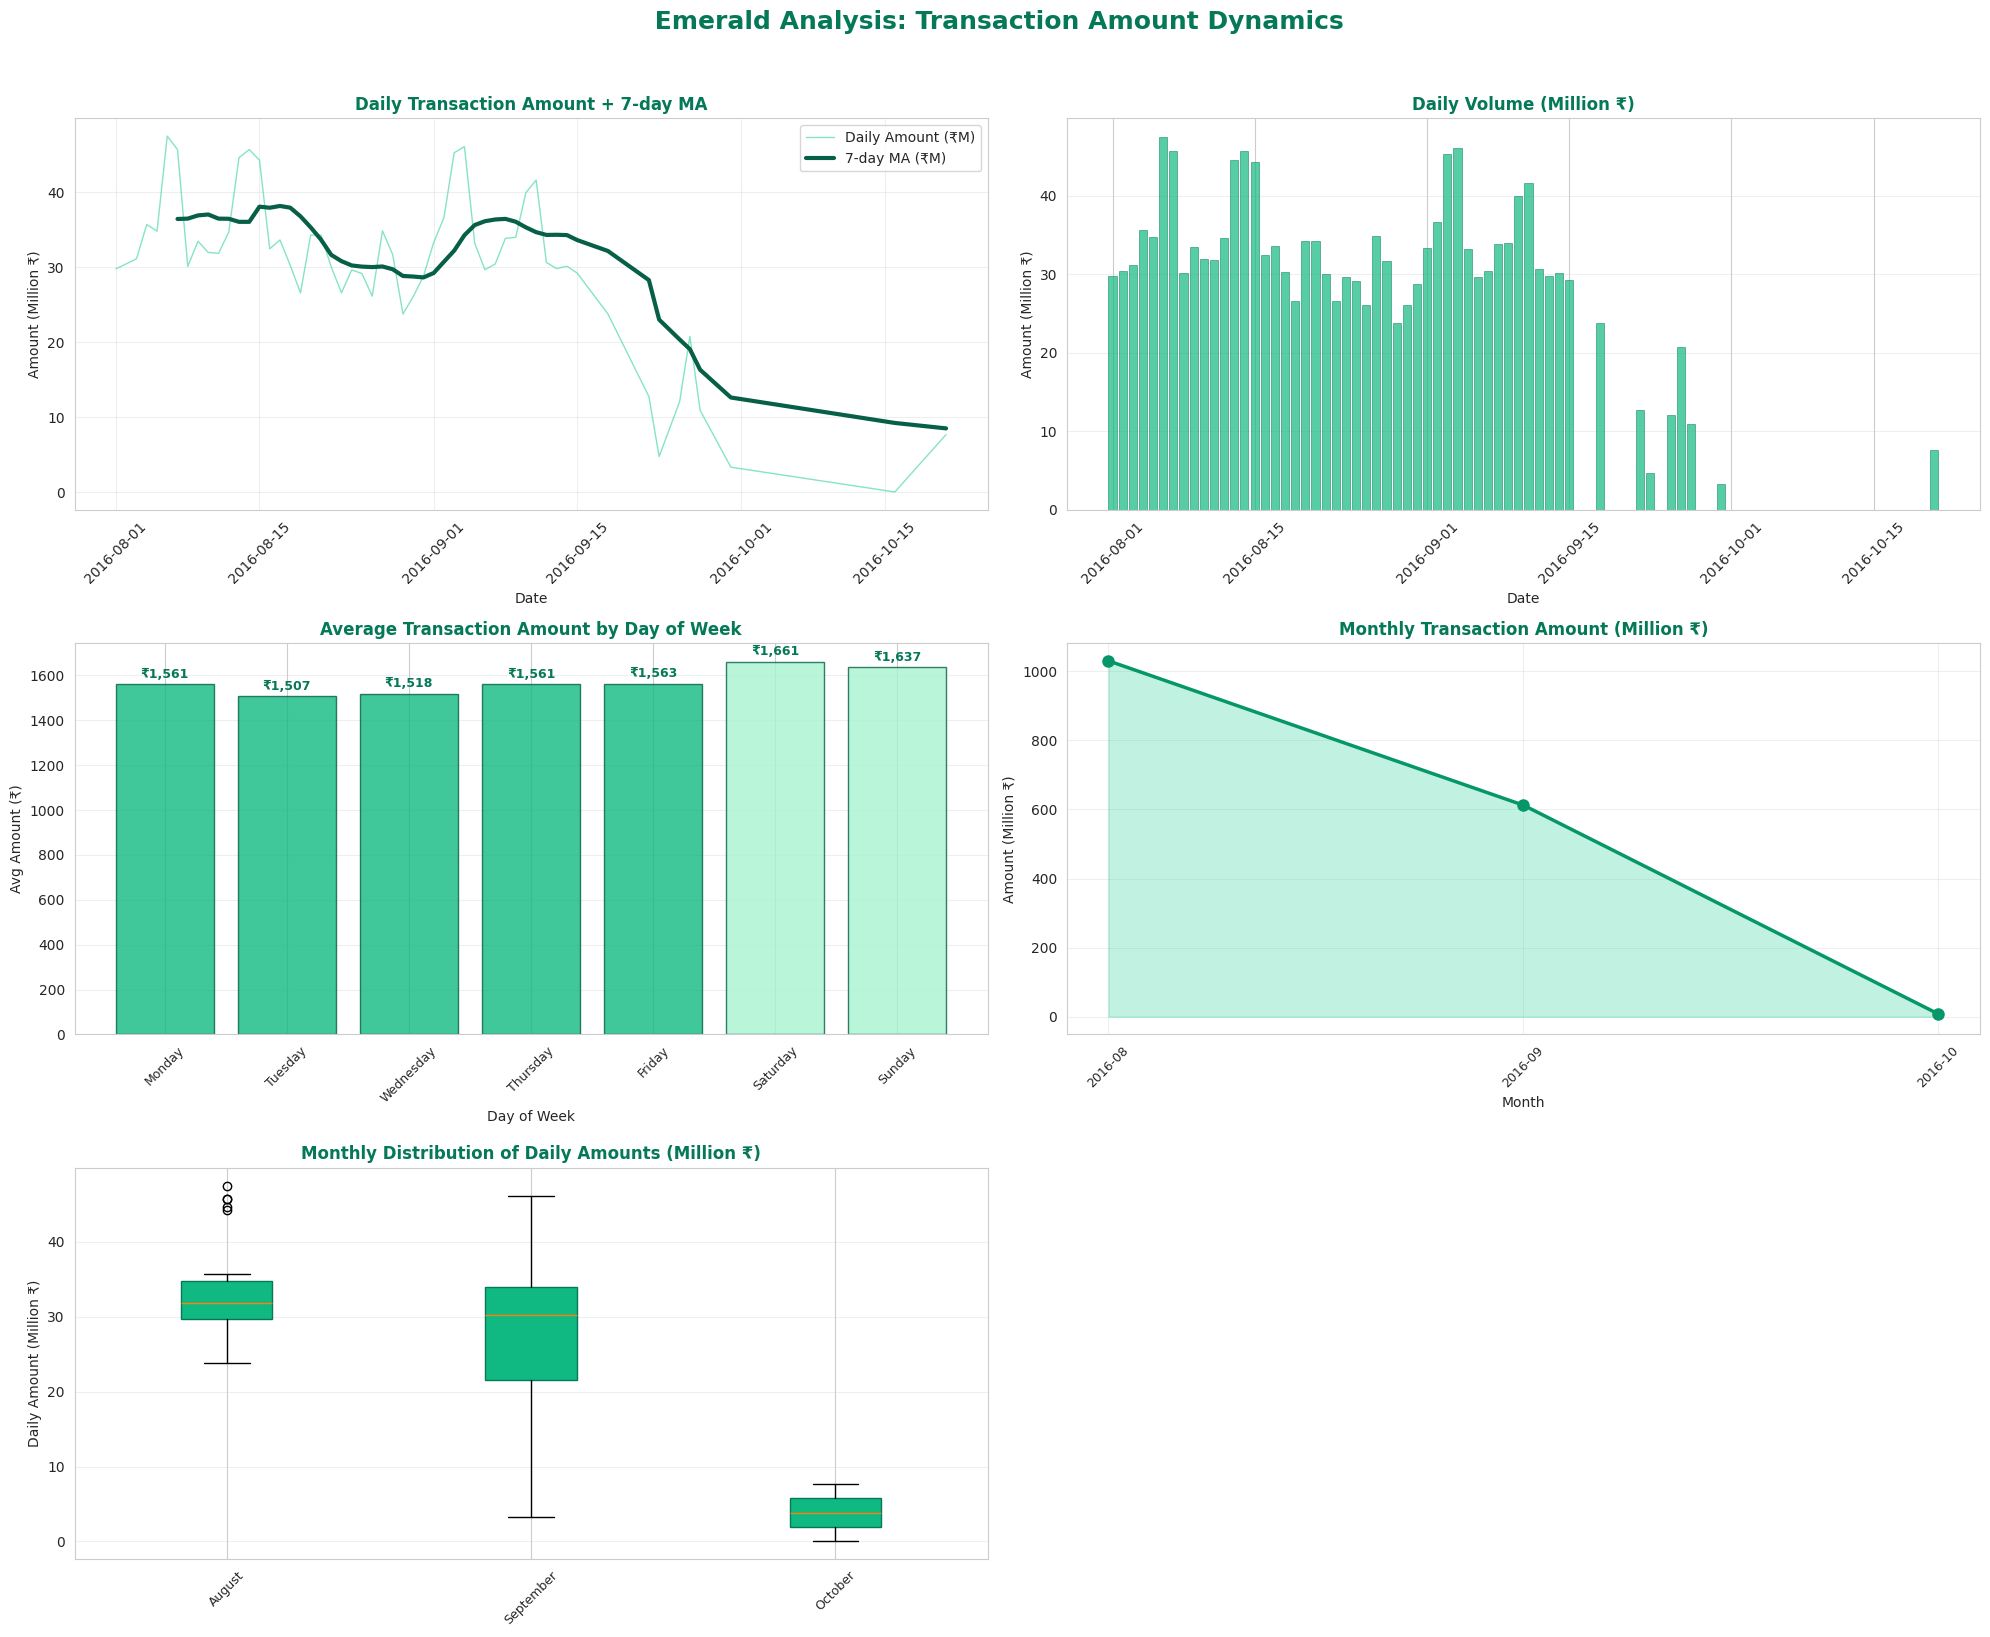

 EMERALD INSIGHTS: AMOUNT DYNAMICS
 Пик оборота: 2016-08-07 (₹45.72M)
 Минимум: 2016-10-16 (₹0.00M)
 Лучший день недели: Sunday (₹281.06M)
 Самый тихий день: Friday (₹208.62M)
 Спад оборота: -24.1% (вторая половина периода)
 Высокая волатильность: CV=0.34 (неравномерный денежный поток)

 Средний чек: ₹1,574.33
 Медианный чек: ₹430.00


In [83]:
# посмотреть динамику транзакций по дате (в сумме TransactionAmount)

# 1. ПОДГОТОВКА ДАННЫХ

print("Анализ динамики сумм транзакций...")

df_work = df.copy()

# Извлекаем дату
df_work['transactionDate'] = df_work['transactionDateTime'].dt.date

# Агрегация по датам - СУММА вместо количества
daily_amount = df_work.groupby('transactionDate').agg({
    'transactionId': 'count',  # количество для справки
    'transactionAmountInr': ['sum', 'mean', 'median', 'std', 'min', 'max']
}).round(2)

daily_amount.columns = ['txn_count', 'total_amount', 'avg_amount', 'median_amount', 'std_amount', 'min_amount', 'max_amount']
daily_amount = daily_amount.reset_index()
daily_amount['transactionDate'] = pd.to_datetime(daily_amount['transactionDate'])

# Скользящее среднее (7 дней)
daily_amount['rolling_7d'] = daily_amount['total_amount'].rolling(window=7).mean()

# Статистика
total_days = len(daily_amount)
total_amount = df_work['transactionAmountInr'].sum()
total_txn = len(df_work)
avg_daily_amount = total_amount / total_days
avg_txn_amount = total_amount / total_txn


print(" ФИНАНСОВАЯ СТАТИСТИКА")

print(f"Период: {daily_amount['transactionDate'].min().date()} — {daily_amount['transactionDate'].max().date()}")
print(f"Всего дней: {total_days}")
print(f"Общий объём транзакций: ₹{total_amount:,.2f}")
print(f"Средний дневной оборот: ₹{avg_daily_amount:,.2f}")
print(f"Средняя транзакция: ₹{avg_txn_amount:,.2f}")
print(f"\n Топ-5 дней по объёму:")
top5_days = daily_amount.nlargest(5, 'total_amount')
for i, row in top5_days.iterrows():
    print(f"   {row['transactionDate'].date()}: ₹{row['total_amount']:,.2f} ({row['txn_count']:,.0f} транзакций)")


# 2. ВИЗУАЛИЗАЦИЯ

fig = plt.figure(figsize=(20, 16))
fig.suptitle(' Emerald Analysis: Transaction Amount Dynamics',
             fontsize=18, fontweight='bold', color=EMERALD[1], y=1.02)

# 1. Основная динамика сумм (линия + скользящее среднее)
ax1 = plt.subplot(3, 2, 1)
ax1.plot(daily_amount['transactionDate'], daily_amount['total_amount']/1e6,
         color=EMERALD[4], linewidth=1, alpha=0.6, label='Daily Amount (₹M)')
ax1.plot(daily_amount['transactionDate'], daily_amount['rolling_7d']/1e6,
         color=EMERALD[0], linewidth=3, label='7-day MA (₹M)')
ax1.set_title('Daily Transaction Amount + 7-day MA', fontweight='bold', color=EMERALD[1], fontsize=12)
ax1.set_xlabel('Date'); ax1.set_ylabel('Amount (Million ₹)')
ax1.legend(loc='upper right'); ax1.grid(alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Столбчатая диаграмма сумм по дням
ax2 = plt.subplot(3, 2, 2)
ax2.bar(daily_amount['transactionDate'], daily_amount['total_amount']/1e6,
        color=EMERALD[3], edgecolor=EMERALD[1], alpha=0.7, linewidth=0.5)
ax2.set_title('Daily Volume (Million ₹)', fontweight='bold', color=EMERALD[1], fontsize=12)
ax2.set_xlabel('Date'); ax2.set_ylabel('Amount (Million ₹)')
ax2.grid(alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

# 3. Средний чек по дням недели
ax3 = plt.subplot(3, 2, 3)
df_work['dayofweek_name'] = df_work['transactionDateTime'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_amount = df_work.groupby('dayofweek_name')['transactionAmountInr'].sum().reindex(dow_order)
dow_count = df_work.groupby('dayofweek_name')['transactionId'].count().reindex(dow_order)
dow_avg = dow_amount / dow_count

bars = ax3.bar(dow_avg.index, dow_avg.values,
               color=[EMERALD[3] if i < 5 else EMERALD[5] for i in range(7)],
               edgecolor=EMERALD[0], alpha=0.8)
ax3.set_title('Average Transaction Amount by Day of Week', fontweight='bold', color=EMERALD[1], fontsize=12)
ax3.set_ylabel('Avg Amount (₹)'); ax3.set_xlabel('Day of Week')
ax3.tick_params(axis='x', rotation=45, labelsize=9)
ax3.grid(alpha=0.3, axis='y')

for bar, avg in zip(bars, dow_avg.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + avg*0.01,
             f'₹{avg:,.0f}', ha='center', va='bottom', fontsize=9, color=EMERALD[1], fontweight='bold')

# 4. Месячная динамика сумм
ax4 = plt.subplot(3, 2, 4)
df_work['month_year'] = df_work['transactionDateTime'].dt.to_period('M')
monthly_amount = df_work.groupby('month_year')['transactionAmountInr'].sum()

ax4.plot(monthly_amount.index.astype(str), monthly_amount.values/1e6,
         marker='o', color=EMERALD[2], linewidth=2.5, markersize=8)
ax4.fill_between(monthly_amount.index.astype(str), monthly_amount.values/1e6,
                 alpha=0.3, color=EMERALD[4])
ax4.set_title('Monthly Transaction Amount (Million ₹)', fontweight='bold', color=EMERALD[1], fontsize=12)
ax4.set_xlabel('Month'); ax4.set_ylabel('Amount (Million ₹)')
ax4.tick_params(axis='x', rotation=45, labelsize=9)
ax4.grid(alpha=0.3)

# 5. Распределение сумм по месяцам (boxplot)
ax5 = plt.subplot(3, 2, 5)
daily_amount['month_name'] = daily_amount['transactionDate'].dt.month_name()
month_order = ['August', 'September', 'October']
months_present = [m for m in month_order if m in daily_amount['month_name'].unique()]

box_data = [daily_amount[daily_amount['month_name']==m]['total_amount'].values/1e6 for m in months_present if len(daily_amount[daily_amount['month_name']==m]) > 0]
months_for_box = [m for m in months_present if len(daily_amount[daily_amount['month_name']==m]) > 0]

bp = ax5.boxplot(box_data, labels=months_for_box, patch_artist=True, whis=1.5)
for patch in bp['boxes']:
    patch.set_facecolor(EMERALD[3])
    patch.set_edgecolor(EMERALD[1])
ax5.set_title('Monthly Distribution of Daily Amounts (Million ₹)', fontweight='bold', color=EMERALD[1], fontsize=12)
ax5.tick_params(axis='x', rotation=45, labelsize=9)
ax5.set_ylabel('Daily Amount (Million ₹)'); ax5.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('emerald_transaction_amount_dynamics.png', dpi=300, bbox_inches='tight',
            facecolor=EMERALD[6])
plt.show()


# 3. КЛЮЧЕВЫЕ ИНСАЙТЫ

print(" EMERALD INSIGHTS: AMOUNT DYNAMICS")


print(f" Пик оборота: {peak_day['transactionDate'].date()} (₹{peak_day['total_amount']/1e6:,.2f}M)")
print(f" Минимум: {low_day['transactionDate'].date()} (₹{low_day['total_amount']/1e6:,.2f}M)")

# Лучший день недели по сумме
if len(dow_amount) > 0:
    best_dow = dow_amount.idxmax()
    worst_dow = dow_amount.idxmin()
    print(f" Лучший день недели: {best_dow} (₹{dow_amount.max()/1e6:,.2f}M)")
    print(f" Самый тихий день: {worst_dow} (₹{dow_amount.min()/1e6:,.2f}M)")
# Тренд
first_half = daily_amount.head(len(daily_amount)//2)['total_amount'].mean()
second_half = daily_amount.tail(len(daily_amount)//2)['total_amount'].mean()
growth = (second_half - first_half) / first_half * 100 if first_half > 0 else 0

if growth > 10:
    print(f" Рост оборота: +{growth:.1f}% (вторая половина периода)")
elif growth < -10:
    print(f" Спад оборота: {growth:.1f}% (вторая половина периода)")
else:
    print(f" Стабильный оборот (изменение: {growth:+.1f}%)")

# Волатильность
if cv > 0.3:
    print(f" Высокая волатильность: CV={cv:.2f} (неравномерный денежный поток)")
else:
    print(f" Стабильный поток: CV={cv:.2f} (равномерный денежный поток)")

# Средний чек
print(f"\n Средний чек: ₹{avg_txn_amount:,.2f}")
print(f" Медианный чек: ₹{daily_amount['median_amount'].median():,.2f}")


Объём транзакций демонстрирует катастрофическое падение: среднедневной оборот сократился с ₹30-35 млн в августе до менее ₹10 млн к середине октября (падение на ~75%), при этом общий объём транзакций уменьшился с ₹1 млрд в августе до практически нуля в октябре. Средний чек остаётся стабильным на уровне ₹1 500-1 660 во все дни, но в выходные немного выше и это указывает на сохранение поведения клиентов, но резкое сокращение количества операций. Высокая волатильность и устойчивый нисходящий тренд подтверждает наличие  системных проблем.

 Сегментация клиентов по возрасту...
 АНАЛИЗ ПЛАТЕЖЕСПОСОБНОСТИ ПО ВОЗРАСТНЫМ ГРУППАМ
           unique_customers  txn_count   total_amount  avg_txn_amount  median_txn_amount  avg_balance  median_balance  total_amount_million  amount_per_customer
age_group                                                                                                                                                       
18-24                213783     222062 185,681,960.39          836.17             237.00    32,875.00        8,444.73                185.68               868.55
25-34                484480     529451 684,086,642.31        1,292.07             409.00    75,823.62       16,014.77                684.09             1,412.00
35-44                156942     161502 341,534,260.89        2,114.74             708.00   182,088.73       30,455.92                341.53             2,176.18
45-54                 46656      47123 135,170,407.47        2,868.46             925.00   304,167.33       4

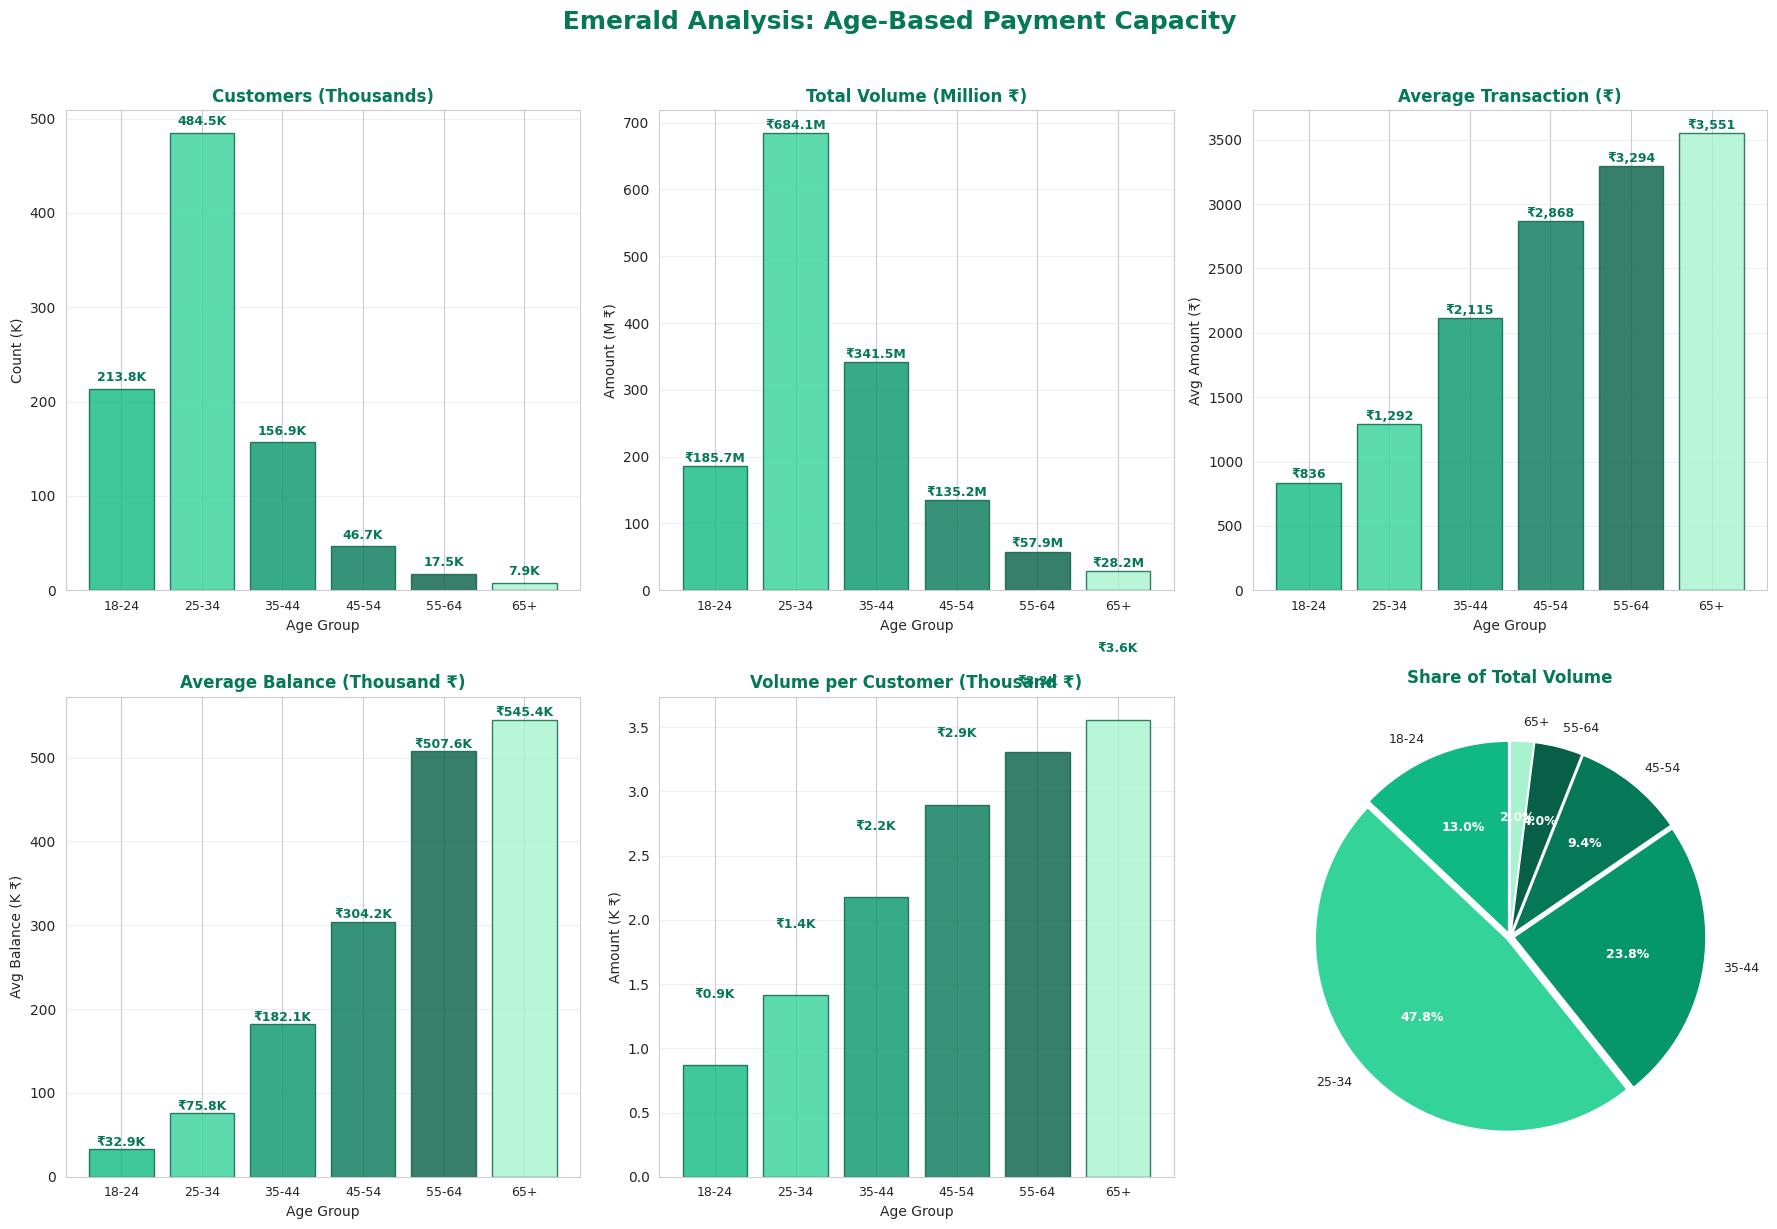

In [84]:
# разбить клиентов на корзины по возрасту и определить самую платежеспособную группу

# 1. ПОДГОТОВКА ДАННЫХ

print(" Сегментация клиентов по возрасту...")

df_work = df.copy()

# Конвертируем только customerDob
df_work['customerDob'] = pd.to_datetime(df_work['customerDob'], errors='coerce')
df_work['transactionDateTime'] = pd.to_datetime(df_work['transactionDateTime'], errors='coerce')

# Извлекаем дату из transactionDateTime для расчёта возраста
df_work['transactionDate_only'] = df_work['transactionDateTime'].dt.date

# Рассчитываем возраст на дату транзакции
df_work['age_at_transaction'] = (df_work['transactionDateTime'] - df_work['customerDob']).dt.days / 365.25

# 2. ВОЗРАСТНЫЕ КОРЗИНЫ

age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

df_work['age_group'] = pd.cut(df_work['age_at_transaction'],
                               bins=age_bins,
                               labels=age_labels,
                               right=True)


# 3. АГРЕГАЦИЯ ПО ГРУППАМ

age_analysis = df_work.groupby('age_group').agg({
    'customerId': 'nunique',
    'transactionId': 'count',
    'transactionAmountInr': ['sum', 'mean', 'median'],
    'custAccountBalance': ['mean', 'median']
}).round(2)

age_analysis.columns = ['unique_customers', 'txn_count', 'total_amount',
                        'avg_txn_amount', 'median_txn_amount',
                        'avg_balance', 'median_balance']

# Дополнительные метрики
age_analysis['total_amount_million'] = age_analysis['total_amount'] / 1e6
age_analysis['amount_per_customer'] = age_analysis['total_amount'] / age_analysis['unique_customers']


print(" АНАЛИЗ ПЛАТЕЖЕСПОСОБНОСТИ ПО ВОЗРАСТНЫМ ГРУППАМ")

print(age_analysis.to_string())


# 4. ОПРЕДЕЛЕНИЕ ЛИДЕРА

winner = age_analysis.loc[age_analysis['total_amount'].idxmax()]

print(f" САМАЯ ПЛАТЕЖЕСПОСОБНАЯ ГРУППА: {winner.name}")

print(f"   • Клиентов: {winner['unique_customers']:,}")
print(f"   • Транзакций: {winner['txn_count']:,}")
print(f"   • Общий объём: ₹{winner['total_amount']/1e6:,.2f}M")
print(f"   • Средний чек: ₹{winner['avg_txn_amount']:,.2f}")
print(f"   • Средний баланс: ₹{winner['avg_balance']:,.2f}")
print(f"   • На клиента: ₹{winner['amount_per_customer']:,.2f}")
print(f"   • Доля оборота: {winner['total_amount']/age_analysis['total_amount'].sum()*100:.1f}%")


# 5. ВИЗУАЛИЗАЦИЯ

fig = plt.figure(figsize=(18, 12))
fig.suptitle(' Emerald Analysis: Age-Based Payment Capacity',
             fontsize=18, fontweight='bold', color=EMERALD[1], y=1.02)

# 1. Количество клиентов
ax1 = plt.subplot(2, 3, 1)
bars1 = ax1.bar(age_analysis.index, age_analysis['unique_customers']/1000,
                color=[EMERALD[i] for i in [3, 4, 2, 1, 0, 5]],
                edgecolor=EMERALD[0], alpha=0.8)
ax1.set_title('Customers (Thousands)', fontweight='bold', color=EMERALD[1])
ax1.set_ylabel('Count (K)'); ax1.set_xlabel('Age Group')
ax1.tick_params(axis='x', rotation=0, labelsize=9)
ax1.grid(alpha=0.3, axis='y')

for bar, count in zip(bars1, age_analysis['unique_customers'].values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count/1000:.1f}K', ha='center', va='bottom',
             fontsize=9, color=EMERALD[1], fontweight='bold')

# 2. Общий объём транзакций
ax2 = plt.subplot(2, 3, 2)
bars2 = ax2.bar(age_analysis.index, age_analysis['total_amount_million'],
                color=[EMERALD[i] for i in [3, 4, 2, 1, 0, 5]],
                edgecolor=EMERALD[0], alpha=0.8)
ax2.set_title('Total Volume (Million ₹)', fontweight='bold', color=EMERALD[1])
ax2.set_ylabel('Amount (M ₹)'); ax2.set_xlabel('Age Group')
ax2.tick_params(axis='x', rotation=0, labelsize=9)
ax2.grid(alpha=0.3, axis='y')

for bar, amount in zip(bars2, age_analysis['total_amount_million'].values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'₹{amount:.1f}M', ha='center', va='bottom',
             fontsize=9, color=EMERALD[1], fontweight='bold')

# 3. Средний чек
ax3 = plt.subplot(2, 3, 3)
bars3 = ax3.bar(age_analysis.index, age_analysis['avg_txn_amount'],
                color=[EMERALD[i] for i in [3, 4, 2, 1, 0, 5]],
                edgecolor=EMERALD[0], alpha=0.8)
ax3.set_title('Average Transaction (₹)', fontweight='bold', color=EMERALD[1])
ax3.set_ylabel('Avg Amount (₹)'); ax3.set_xlabel('Age Group')
ax3.tick_params(axis='x', rotation=0, labelsize=9)
ax3.grid(alpha=0.3, axis='y')

for bar, avg in zip(bars3, age_analysis['avg_txn_amount'].values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'₹{avg:,.0f}', ha='center', va='bottom',
             fontsize=9, color=EMERALD[1], fontweight='bold')

# 4. Средний баланс
ax4 = plt.subplot(2, 3, 4)
bars4 = ax4.bar(age_analysis.index, age_analysis['avg_balance']/1000,
                color=[EMERALD[i] for i in [3, 4, 2, 1, 0, 5]],
                edgecolor=EMERALD[0], alpha=0.8)
ax4.set_title('Average Balance (Thousand ₹)', fontweight='bold', color=EMERALD[1])
ax4.set_ylabel('Avg Balance (K ₹)'); ax4.set_xlabel('Age Group')
ax4.tick_params(axis='x', rotation=0, labelsize=9)
ax4.grid(alpha=0.3, axis='y')

for bar, bal in zip(bars4, age_analysis['avg_balance'].values/1000):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'₹{bal:,.1f}K', ha='center', va='bottom',
             fontsize=9, color=EMERALD[1], fontweight='bold')

# 5. Объём на клиента
ax5 = plt.subplot(2, 3, 5)
bars5 = ax5.bar(age_analysis.index, age_analysis['amount_per_customer']/1000,
                color=[EMERALD[i] for i in [3, 4, 2, 1, 0, 5]],
                edgecolor=EMERALD[0], alpha=0.8)
ax5.set_title('Volume per Customer (Thousand ₹)', fontweight='bold', color=EMERALD[1])
ax5.set_ylabel('Amount (K ₹)'); ax5.set_xlabel('Age Group')
ax5.tick_params(axis='x', rotation=0, labelsize=9)
ax5.grid(alpha=0.3, axis='y')

for bar, amt in zip(bars5, age_analysis['amount_per_customer'].values/1000):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'₹{amt:,.1f}K', ha='center', va='bottom',
             fontsize=9, color=EMERALD[1], fontweight='bold')

# 6. Pie chart: доля по объёму
ax6 = plt.subplot(2, 3, 6)
colors_pie = [EMERALD[i] for i in [3, 4, 2, 1, 0, 5]]
wedges, texts, autotexts = ax6.pie(age_analysis['total_amount'],
                                    labels=age_analysis.index,
                                    autopct='%1.1f%%',
                                    colors=colors_pie,
                                    startangle=90,
                                    explode=[0.02]*len(age_analysis),
                                    textprops={'fontsize': 9})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax6.set_title('Share of Total Volume', fontweight='bold', color=EMERALD[1], pad=10)

plt.tight_layout()
plt.savefig('emerald_age_payment_capacity.png', dpi=300, bbox_inches='tight',
            facecolor=EMERALD[6])
plt.show()

Основной объём транзакций создаёт молодая аудитория 25-34 лет: эта группа составляет 47,8% от общего оборота (₹684.1 мил.) и представляет наибольшую численность клиентов (484.5 тыс.). Однако с возрастом растёт финансовая ёмкость клиентов: группа 65+ при малой численности (7.9 тыс.) демонстрирует максимальный средний чек (₹3,551) и средний баланс на счёте (₹545.4 тыс.), что в 6-16 раз выше показателей молодых клиентов. Следовательно, молодёжь обеспечивает массовый объём транзакций, а старшие возрастные группы представляют собой премиальный сегмент с высокой платёжеспособностью.

 Анализ топ 10 по кол-ву транзакций к сумме транзакций 
 ТОП-10 ЛОКАЦИЙ ПО КОЛИЧЕСТВУ ТРАНЗАКЦИЙ
№   Локация                  Транзакций    Сумма (M ₹)     Клиентов
1   Mumbai                    103,596.0        179.69M    101,730.0
2   New Delhi                  84,928.0        160.71M     83,564.0
3   Bangalore                  81,555.0        118.42M     80,347.0
4   Gurgaon                    73,818.0        112.09M     72,856.0
5   Delhi                      71,019.0        106.22M     70,067.0
6   Noida                      32,784.0         44.46M     32,570.0
7   Chennai                    30,009.0         44.64M     29,823.0
8   Pune                       25,851.0         39.59M     25,710.0
9   Hyderabad                  23,049.0         36.18M     22,929.0
10  Thane                      21,505.0         27.16M     21,404.0
 ТОП-10 ЛОКАЦИЙ ПО СУММЕ ТРАНЗАКЦИЙ
№   Локация                 Сумма (M ₹)     Транзакций    Ср. чек (₹)
1   Mumbai                      179.69M      103,

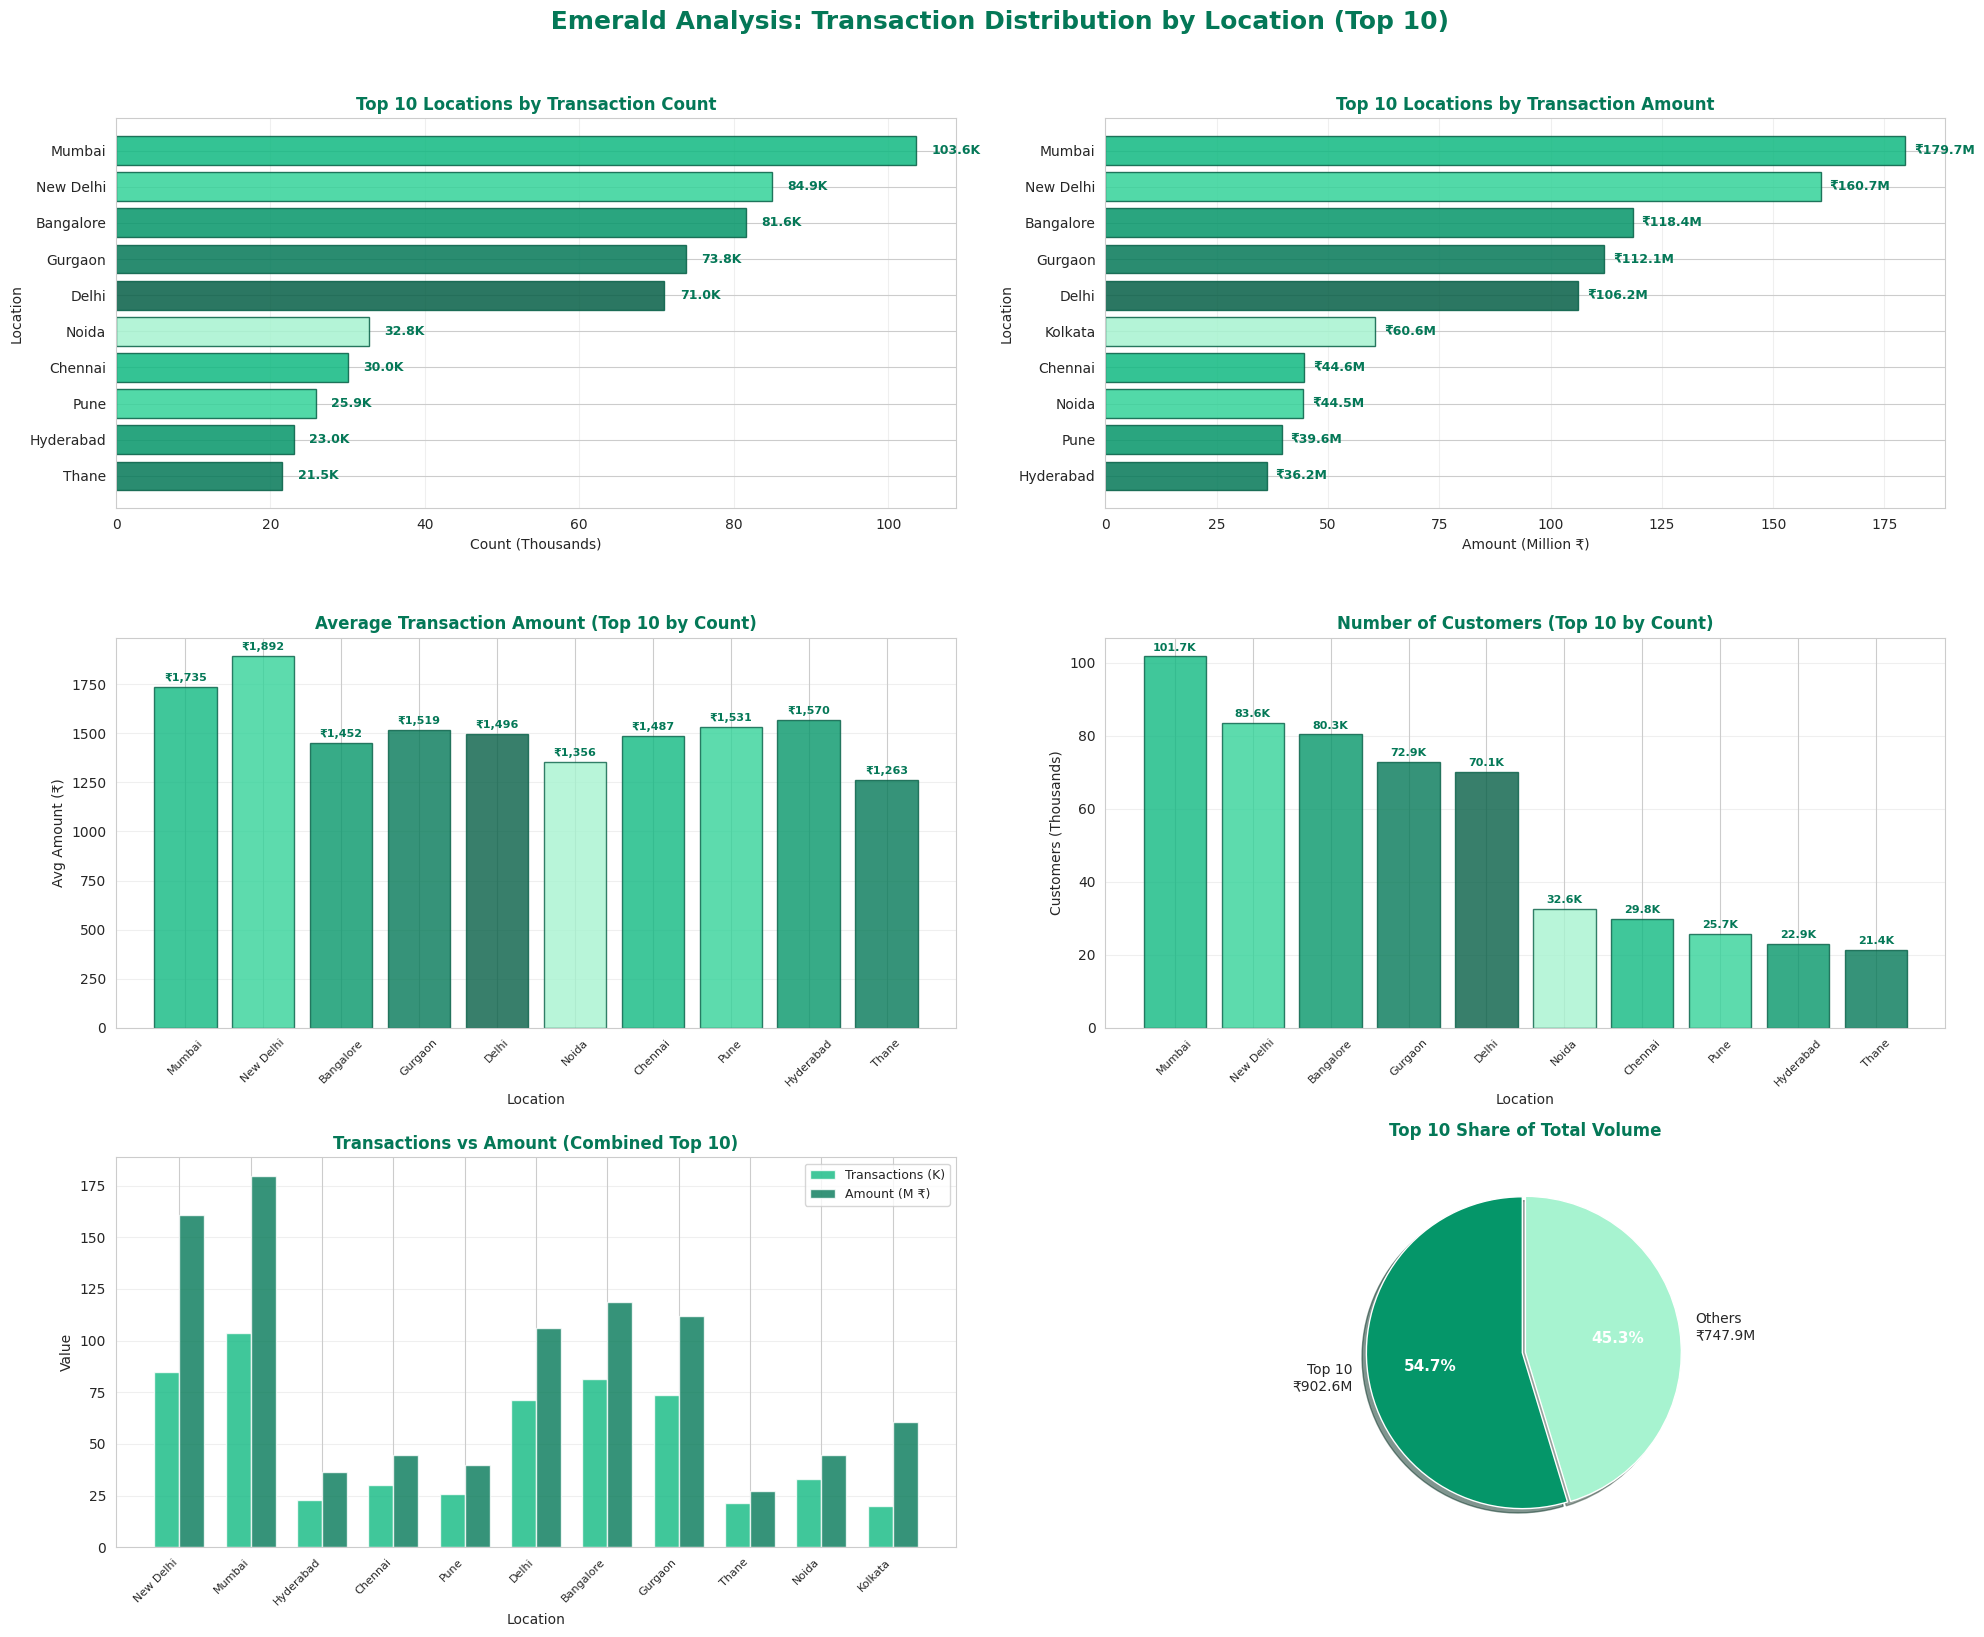

 Анализ локации по кол-ву транзакций к сумме транзакций
 Лидер по количеству: Mumbai (103,596.0 транзакций)
 Лидер по объёму: Mumbai (₹179.69M)

 Концентрация топ-10:
   • По количеству: 52.3% всех транзакций
   • По сумме: 54.7% всего объёма

 Различия в топ-10:
   • В обоих рейтингах: 9 локаций
   • Только по количеству: Thane
   • Только по сумме: Kolkata

 Самый высокий средний чек: Roomford (₹117,621.00)


In [85]:
# посмотреть распределение транзакций по локации – вывести топ 10 по кол-ву транзакций/сумме транзакций

print(" Анализ топ 10 по кол-ву транзакций к сумме транзакций ")

df_work = df.copy()

# Очистка локаций
df_work['custLocation'] = df_work['custLocation'].astype(str).str.strip().str.title()
df_work = df_work[~df_work['custLocation'].isin(['Nan', 'Na', 'Unknown', ''])]


# 2. АГРЕГАЦИЯ ПО ЛОКАЦИЯМ

location_stats = df_work.groupby('custLocation').agg({
    'transactionId': 'count',
    'transactionAmountInr': ['sum', 'mean', 'median'],
    'customerId': 'nunique',
    'custAccountBalance': 'mean'
}).round(2)

location_stats.columns = ['txn_count', 'total_amount', 'avg_txn_amount',
                          'median_txn_amount', 'unique_customers', 'avg_balance']

# Дополнительные метрики
location_stats['total_amount_million'] = location_stats['total_amount'] / 1e6
location_stats['txn_per_customer'] = location_stats['txn_count'] / location_stats['unique_customers']


# 3. ТОП-10 ПО КОЛИЧЕСТВУ ТРАНЗАКЦИЙ

top10_by_count = location_stats.nlargest(10, 'txn_count')


print(" ТОП-10 ЛОКАЦИЙ ПО КОЛИЧЕСТВУ ТРАНЗАКЦИЙ")

print(f"{'№':<3} {'Локация':<20} {'Транзакций':>14} {'Сумма (M ₹)':>14} {'Клиентов':>12}")


for i, (loc, row) in enumerate(top10_by_count.iterrows(), 1):
    print(f"{i:<3} {loc:<20} {row['txn_count']:>14,} {row['total_amount_million']:>13.2f}M {row['unique_customers']:>12,}")


# 4. ТОП-10 ПО СУММЕ ТРАНЗАКЦИЙ

top10_by_amount = location_stats.nlargest(10, 'total_amount')


print(" ТОП-10 ЛОКАЦИЙ ПО СУММЕ ТРАНЗАКЦИЙ")

print(f"{'№':<3} {'Локация':<20} {'Сумма (M ₹)':>14} {'Транзакций':>14} {'Ср. чек (₹)':>14}")


for i, (loc, row) in enumerate(top10_by_amount.iterrows(), 1):
    print(f"{i:<3} {loc:<20} {row['total_amount_million']:>13.2f}M {row['txn_count']:>14,} {row['avg_txn_amount']:>13,.2f}")


# 5. ВИЗУАЛИЗАЦИЯ

fig = plt.figure(figsize=(20, 16))
fig.suptitle(' Emerald Analysis: Transaction Distribution by Location (Top 10)',
             fontsize=18, fontweight='bold', color=EMERALD[1], y=1.02)

# 1. Топ-10 по количеству транзакций (горизонтальный bar)
ax1 = plt.subplot(3, 2, 1)
bars1 = ax1.barh(top10_by_count.index[::-1], top10_by_count['txn_count'][::-1]/1000,
                 color=[EMERALD[i] for i in [3, 4, 2, 1, 0, 5, 3, 4, 2, 1]][::-1],
                 edgecolor=EMERALD[0], alpha=0.85)
ax1.set_title('Top 10 Locations by Transaction Count', fontweight='bold', color=EMERALD[1], fontsize=12)
ax1.set_xlabel('Count (Thousands)'); ax1.set_ylabel('Location')
ax1.grid(alpha=0.3, axis='x')

for bar, count in zip(bars1, top10_by_count['txn_count'][::-1]):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f'{count/1000:.1f}K', va='center', fontsize=9, color=EMERALD[1], fontweight='bold')

# 2. Топ-10 по сумме транзакций (горизонтальный bar)
ax2 = plt.subplot(3, 2, 2)
bars2 = ax2.barh(top10_by_amount.index[::-1], top10_by_amount['total_amount_million'][::-1],
                 color=[EMERALD[i] for i in [3, 4, 2, 1, 0, 5, 3, 4, 2, 1]][::-1],
                 edgecolor=EMERALD[0], alpha=0.85)
ax2.set_title('Top 10 Locations by Transaction Amount', fontweight='bold', color=EMERALD[1], fontsize=12)
ax2.set_xlabel('Amount (Million ₹)'); ax2.set_ylabel('Location')
ax2.grid(alpha=0.3, axis='x')

for bar, amount in zip(bars2, top10_by_amount['total_amount_million'][::-1]):
    ax2.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f'₹{amount:.1f}M', va='center', fontsize=9, color=EMERALD[1], fontweight='bold')

# 3. Средний чек по топ-10 локациям (по количеству)
ax3 = plt.subplot(3, 2, 3)
bars3 = ax3.bar(top10_by_count.index, top10_by_count['avg_txn_amount'],
                color=[EMERALD[i] for i in [3, 4, 2, 1, 0, 5, 3, 4, 2, 1]],
                edgecolor=EMERALD[0], alpha=0.8)
ax3.set_title('Average Transaction Amount (Top 10 by Count)', fontweight='bold', color=EMERALD[1], fontsize=12)
ax3.set_ylabel('Avg Amount (₹)'); ax3.set_xlabel('Location')
ax3.tick_params(axis='x', rotation=45, labelsize=8)
ax3.grid(alpha=0.3, axis='y')

for bar, avg in zip(bars3, top10_by_count['avg_txn_amount'].values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'₹{avg:,.0f}', ha='center', va='bottom', fontsize=8, color=EMERALD[1], fontweight='bold')

# 4. Количество клиентов по топ-10 локациям (по количеству)
ax4 = plt.subplot(3, 2, 4)
bars4 = ax4.bar(top10_by_count.index, top10_by_count['unique_customers']/1000,
                color=[EMERALD[i] for i in [3, 4, 2, 1, 0, 5, 3, 4, 2, 1]],
                edgecolor=EMERALD[0], alpha=0.8)
ax4.set_title('Number of Customers (Top 10 by Count)', fontweight='bold', color=EMERALD[1], fontsize=12)
ax4.set_ylabel('Customers (Thousands)'); ax4.set_xlabel('Location')
ax4.tick_params(axis='x', rotation=45, labelsize=8)
ax4.grid(alpha=0.3, axis='y')

for bar, cust in zip(bars4, top10_by_count['unique_customers'].values/1000):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{cust:.1f}K', ha='center', va='bottom', fontsize=8, color=EMERALD[1], fontweight='bold')

# 5. Сравнение: количество vs сумма (нормализованное)
ax5 = plt.subplot(3, 2, 5)
# Объединяем оба топ-10
combined_locs = list(set(top10_by_count.index) | set(top10_by_amount.index))
combined_data = location_stats.loc[combined_locs]

x = np.arange(len(combined_locs))
width = 0.35

bars_count = ax5.bar(x - width/2, combined_data['txn_count']/1000, width,
                     label='Transactions (K)', color=EMERALD[3], alpha=0.8)
bars_amount = ax5.bar(x + width/2, combined_data['total_amount_million'], width,
                      label='Amount (M ₹)', color=EMERALD[1], alpha=0.8)

ax5.set_title('Transactions vs Amount (Combined Top 10)', fontweight='bold', color=EMERALD[1], fontsize=12)
ax5.set_xlabel('Location'); ax5.set_ylabel('Value')
ax5.set_xticks(x)
ax5.set_xticklabels(combined_locs, rotation=45, ha='right', fontsize=8)
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3, axis='y')

# 6. Pie chart: доля топ-10 в общем объёме
ax6 = plt.subplot(3, 2, 6)
top10_amount_sum = top10_by_amount['total_amount'].sum()
other_amount = location_stats[~location_stats.index.isin(top10_by_amount.index)]['total_amount'].sum()

pie_data = [top10_amount_sum, other_amount]
pie_labels = [f'Top 10\n₹{top10_amount_sum/1e6:,.1f}M', f'Others\n₹{other_amount/1e6:,.1f}M']
colors_pie = [EMERALD[2], EMERALD[5]]

wedges, texts, autotexts = ax6.pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
                                    colors=colors_pie, startangle=90, explode=[0.02, 0],
                                    shadow=True)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax6.set_title('Top 10 Share of Total Volume', fontweight='bold', color=EMERALD[1], pad=15)

plt.tight_layout()
plt.savefig('emerald_location_transaction_analysis.png', dpi=300, bbox_inches='tight',
            facecolor=EMERALD[6])
plt.show()

# 6. КЛЮЧЕВЫЕ ИНСАЙТЫ

print(" Анализ локации по кол-ву транзакций к сумме транзакций")

# Лидер по количеству
count_leader = top10_by_count.iloc[0]
print(f" Лидер по количеству: {top10_by_count.index[0]} ({count_leader['txn_count']:,} транзакций)")

# Лидер по сумме
amount_leader = top10_by_amount.iloc[0]
print(f" Лидер по объёму: {top10_by_amount.index[0]} (₹{amount_leader['total_amount_million']:.2f}M)")

# Концентрация
total_top10_count = top10_by_count['txn_count'].sum()
total_all_count = location_stats['txn_count'].sum()
top10_count_share = total_top10_count / total_all_count * 100

total_top10_amount = top10_by_amount['total_amount'].sum()
total_all_amount = location_stats['total_amount'].sum()
top10_amount_share = total_top10_amount / total_all_amount * 100

print(f"\n Концентрация топ-10:")
print(f"   • По количеству: {top10_count_share:.1f}% всех транзакций")
print(f"   • По сумме: {top10_amount_share:.1f}% всего объёма")

# Различия в рейтингах
count_locs = set(top10_by_count.index)
amount_locs = set(top10_by_amount.index)
in_both = count_locs & amount_locs
only_in_count = count_locs - amount_locs
only_in_amount = amount_locs - count_locs

print(f"\n Различия в топ-10:")
print(f"   • В обоих рейтингах: {len(in_both)} локаций")
if only_in_count:
    print(f"   • Только по количеству: {', '.join(only_in_count)}")
if only_in_amount:
    print(f"   • Только по сумме: {', '.join(only_in_amount)}")

# Средний чек
highest_avg_check = location_stats.loc[location_stats['avg_txn_amount'].idxmax()]
print(f"\n Самый высокий средний чек: {highest_avg_check.name} (₹{highest_avg_check['avg_txn_amount']:,.2f})")



Mumbai является безусловным лидером и занимает первое место по количеству транзакций (103.6 тыс.) и по объёму (₹179.7 мил.), концентрируя 101.7 тыс. клиентов. Топ-10 локаций генерируют 54.7% всего оборота (₹902.6 мил.), показывая высокую географическую концентрацию бизнеса. New Delhi демонстрирует наибольший средний чек (₹1 892), несмотря на второе место по общему объёму. Присутствие Kolkata в топ-10 по сумме (₹60.6 мил.), но отсутствие в топ-10 по количеству транзакций свидетельствует о более высокой платёжеспособности клиентов этого города. Пять мегаполисов (Mumbai, New Delhi, Bangalore, Gurgaon, Delhi) формируют ядро бизнеса, обеспечивая основную долю транзакционной активности.

In [ ]:
df.info()

 Анализ времени транзакций...

 Формат transactionTime:
   Тип: int64
   Примеры: [143207, 141858, 142712, 142714, 181156, 173940, 173806, 170537, 192825, 192446]
   Min: 0, Max: 235959

  Неизвестный формат. Пробуем использовать transactionDateTime...
 СТАТИСТИКА ВРЕМЕНИ ТРАНЗАКЦИЙ

 Распределение по часам:
      txn_count   total_amount  avg_amount
hour                                      
0         17977  24,220,958.52    1,347.33
1          8850  10,742,828.61    1,213.88
2          5552   6,502,762.85    1,171.25
3          4720   5,067,690.40    1,073.66
4          4571   4,536,081.19      992.36
5          5356   5,196,114.64      970.15
6          8217   8,667,566.23    1,054.83
7         14579  15,202,886.51    1,042.79
8         23520  24,467,289.41    1,040.28
9         33094  39,454,481.89    1,192.19
10        42639  54,808,723.95    1,285.41
11        52401  81,187,120.23    1,549.34
12        60863 104,004,666.60    1,708.83
13        65006 115,371,018.93    1,774.77
14

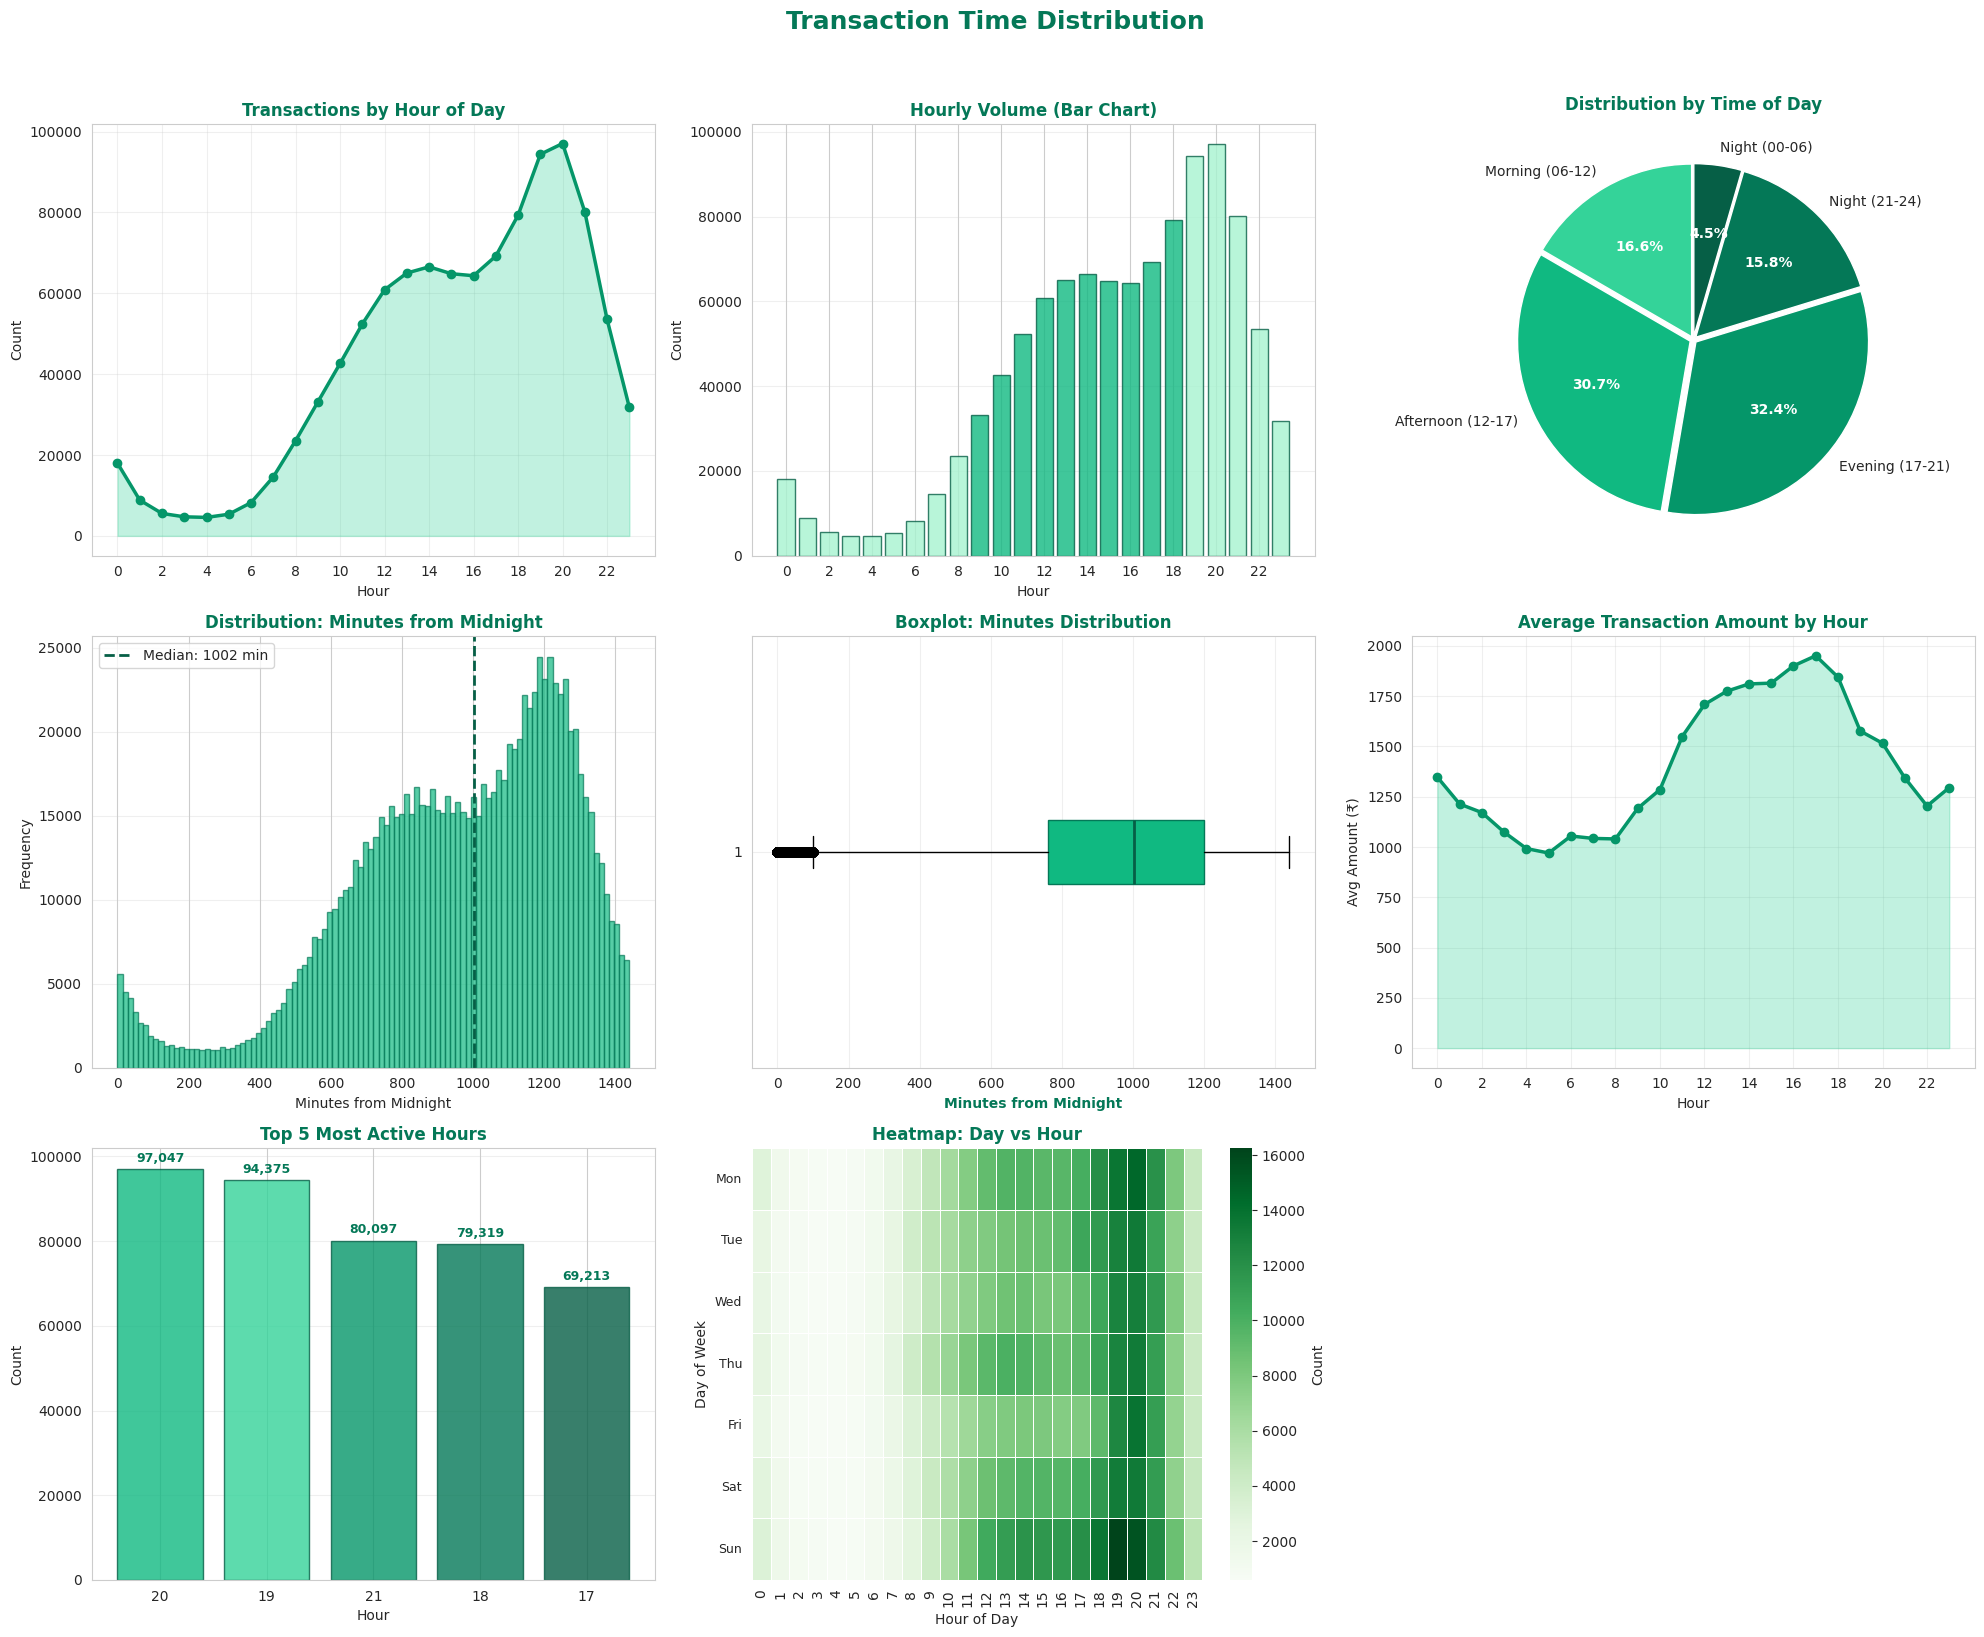

TRANSACTION TIME
 Пик активности: 20:00 (97,047 транзакций)
 Самый тихий час: 04:00 (4,571 транзакций)
 Активный период: Evening (17-21) (32.4%)
 В рабочее время (9-18): 598,268 (57.1%)
 Вне рабочего времени: 450,148 (42.9%)

 Самый высокий средний чек: 17:00 (₹1,951.22)


In [87]:
# посмотреть распределение времени транзакции (TransactionTime). Перевести из миллисекунд в минуты

print(" Анализ времени транзакций...")

df_work = df.copy()

# Проверяем формат transactionTime
print(f"\n Формат transactionTime:")
print(f"   Тип: {df_work['transactionTime'].dtype}")
print(f"   Примеры: {df_work['transactionTime'].head(10).tolist()}")
print(f"   Min: {df_work['transactionTime'].min()}, Max: {df_work['transactionTime'].max()}")

sample_time = df_work['transactionTime'].iloc[0]

# ОПРЕДЕЛЯЕМ ФОРМАТ И КОНВЕРТИРУЕМ
if sample_time > 1000000:  # Скорее всего миллисекунды
    print(f"\n Формат: МИЛЛИСЕКУНДЫ от начала суток")
    print(f"   Пример: {sample_time} мс")

    # Конвертируем миллисекунды в минуты
    df_work['minutes_from_midnight'] = (df_work['transactionTime'] / 1000 / 60).astype(int)

    # Извлекаем часы и минуты
    df_work['hour'] = (df_work['minutes_from_midnight'] // 60).astype(int)
    df_work['minute'] = (df_work['minutes_from_midnight'] % 60).astype(int)

    # Показываем пример конвертации
    print(f"\n Примеры конвертации:")
    print(f"   {df_work['transactionTime'].iloc[0]} мс → "
          f"{df_work['minutes_from_midnight'].iloc[0]} мин → "
          f"{df_work['hour'].iloc[0]:02d}:{df_work['minute'].iloc[0]:02d}")

elif 0 <= sample_time <= 2359:  # Формат HHMM
    print(f"\n Формат: HHMM (часы и минуты)")

    df_work['hour'] = (df_work['transactionTime'] // 100).astype(int)
    df_work['minute'] = (df_work['transactionTime'] % 100).astype(int)
    df_work['minutes_from_midnight'] = df_work['hour'] * 60 + df_work['minute']

else:
    print(f"\n  Неизвестный формат. Пробуем использовать transactionDateTime...")
    df_work['transactionDateTime'] = pd.to_datetime(df_work['transactionDateTime'], errors='coerce')
    df_work['hour'] = df_work['transactionDateTime'].dt.hour
    df_work['minute'] = df_work['transactionDateTime'].dt.minute
    df_work['minutes_from_midnight'] = df_work['hour'] * 60 + df_work['minute']

# Фильтруем корректное время (0-23 часа)
df_work = df_work[(df_work['hour'] >= 0) & (df_work['hour'] <= 23)].copy()

# Определяем время суток
def get_time_of_day(hour):
    if 0 <= hour < 6:
        return 'Night (00-06)'
    elif 6 <= hour < 12:
        return 'Morning (06-12)'
    elif 12 <= hour < 17:
        return 'Afternoon (12-17)'
    elif 17 <= hour < 21:
        return 'Evening (17-21)'
    else:
        return 'Night (21-24)'

df_work['time_of_day'] = df_work['hour'].apply(get_time_of_day)

# 2. СТАТИСТИКА


print(" СТАТИСТИКА ВРЕМЕНИ ТРАНЗАКЦИЙ")


print(f"\n Распределение по часам:")
hourly_dist = df_work.groupby('hour').agg({
    'transactionId': 'count',
    'transactionAmountInr': ['sum', 'mean']
}).round(2)
hourly_dist.columns = ['txn_count', 'total_amount', 'avg_amount']
print(hourly_dist.to_string())

print(f"\n По времени суток:")
time_of_day_stats = df_work.groupby('time_of_day').agg({
    'transactionId': 'count',
    'transactionAmountInr': ['sum', 'mean']
}).round(2)
time_of_day_stats.columns = ['txn_count', 'total_amount', 'avg_amount']
time_of_day_stats['share'] = time_of_day_stats['txn_count'] / len(df_work) * 100
print(time_of_day_stats.to_string())


# 3. ВИЗУАЛИЗАЦИЯ

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Transaction Time Distribution',
             fontsize=18, fontweight='bold', color=EMERALD[1], y=1.02)

# 1. Распределение по часам (линия)
ax1 = plt.subplot(3, 3, 1)
hourly_counts = df_work.groupby('hour')['transactionId'].count()
ax1.plot(hourly_counts.index, hourly_counts.values,
         marker='o', color=EMERALD[2], linewidth=2.5, markersize=6)
ax1.fill_between(hourly_counts.index, hourly_counts.values, alpha=0.3, color=EMERALD[4])
ax1.set_title('Transactions by Hour of Day', fontweight='bold', color=EMERALD[1])
ax1.set_xlabel('Hour'); ax1.set_ylabel('Count')
ax1.set_xticks(range(0, 24, 2))
ax1.grid(alpha=0.3)

# 2. Распределение по часам (bar)
ax2 = plt.subplot(3, 3, 2)
bars2 = ax2.bar(hourly_counts.index, hourly_counts.values,
                color=[EMERALD[3] if 9 <= h <= 18 else EMERALD[5] for h in range(24)],
                edgecolor=EMERALD[0], alpha=0.8)
ax2.set_title('Hourly Volume (Bar Chart)', fontweight='bold', color=EMERALD[1])
ax2.set_xlabel('Hour'); ax2.set_ylabel('Count')
ax2.set_xticks(range(0, 24, 2))
ax2.grid(alpha=0.3, axis='y')

# 3. Распределение по времени суток (pie)
ax3 = plt.subplot(3, 3, 3)
time_of_day_order = ['Morning (06-12)', 'Afternoon (12-17)', 'Evening (17-21)', 'Night (21-24)', 'Night (00-06)']
time_of_day_counts = df_work.groupby('time_of_day')['transactionId'].count()
time_of_day_counts = time_of_day_counts.reindex(time_of_day_order)

colors_pie = [EMERALD[4], EMERALD[3], EMERALD[2], EMERALD[1], EMERALD[0]]
wedges, texts, autotexts = ax3.pie(time_of_day_counts.values,
                                    labels=time_of_day_counts.index,
                                    autopct='%1.1f%%',
                                    colors=colors_pie[:len(time_of_day_counts)],
                                    startangle=90, explode=[0.02]*len(time_of_day_counts))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax3.set_title('Distribution by Time of Day', fontweight='bold', color=EMERALD[1], pad=10)

# 4. Гистограмма минут от полуночи
ax4 = plt.subplot(3, 3, 4)
ax4.hist(df_work['minutes_from_midnight'], bins=100,
         color=EMERALD[3], edgecolor=EMERALD[1], alpha=0.7)
ax4.axvline(df_work['minutes_from_midnight'].median(),
            color=EMERALD[0], linestyle='--', linewidth=2,
            label=f"Median: {df_work['minutes_from_midnight'].median():.0f} min")
ax4.set_title('Distribution: Minutes from Midnight', fontweight='bold', color=EMERALD[1])
ax4.set_xlabel('Minutes from Midnight'); ax4.set_ylabel('Frequency')
ax4.legend(); ax4.grid(alpha=0.3, axis='y')

# 5. Boxplot минут
ax5 = plt.subplot(3, 3, 5)
ax5.boxplot([df_work['minutes_from_midnight']], vert=False, patch_artist=True,
            boxprops=dict(facecolor=EMERALD[3], color=EMERALD[1]),
            medianprops=dict(color=EMERALD[0], linewidth=2))
ax5.set_xlabel('Minutes from Midnight', fontweight='bold', color=EMERALD[1])
ax5.set_title('Boxplot: Minutes Distribution', fontweight='bold', color=EMERALD[1])
ax5.grid(alpha=0.3)

# 6. Средний чек по часам
ax6 = plt.subplot(3, 3, 6)
hourly_avg = df_work.groupby('hour')['transactionAmountInr'].mean()
ax6.plot(hourly_avg.index, hourly_avg.values,
         marker='o', color=EMERALD[2], linewidth=2.5, markersize=6)
ax6.fill_between(hourly_avg.index, hourly_avg.values, alpha=0.3, color=EMERALD[4])
ax6.set_title('Average Transaction Amount by Hour', fontweight='bold', color=EMERALD[1])
ax6.set_xlabel('Hour'); ax6.set_ylabel('Avg Amount (₹)')
ax6.set_xticks(range(0, 24, 2))
ax6.grid(alpha=0.3)

# 7. Топ-5 самых активных часов
ax7 = plt.subplot(3, 3, 7)
top5_hours = hourly_counts.nlargest(5)
bars7 = ax7.bar(top5_hours.index.astype(str), top5_hours.values,
                color=[EMERALD[i] for i in [3, 4, 2, 1, 0]],
                edgecolor=EMERALD[0], alpha=0.8)
ax7.set_title('Top 5 Most Active Hours', fontweight='bold', color=EMERALD[1])
ax7.set_ylabel('Count'); ax7.set_xlabel('Hour')
ax7.grid(alpha=0.3, axis='y')

for bar, count in zip(bars7, top5_hours.values):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{count:,}', ha='center', va='bottom', fontsize=9, color=EMERALD[1], fontweight='bold')

# 8. Heatmap: день недели × час
ax8 = plt.subplot(3, 3, 8)
if 'transactionDateTime' in df_work.columns:
    df_work['transactionDateTime'] = pd.to_datetime(df_work['transactionDateTime'], errors='coerce')
    df_work['dayofweek'] = df_work['transactionDateTime'].dt.dayofweek

    heatmap_data = pd.crosstab(df_work['dayofweek'], df_work['hour'])
    day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    heatmap_data = heatmap_data.reindex(range(7))

    sns.heatmap(heatmap_data, ax=ax8, cmap='Greens', cbar_kws={'label': 'Count'},
                linewidths=0.5, linecolor='white')
    ax8.set_yticklabels(day_names, rotation=0, fontsize=9)
    ax8.set_title('Heatmap: Day vs Hour', fontweight='bold', color=EMERALD[1])
    ax8.set_xlabel('Hour of Day'); ax8.set_ylabel('Day of Week')
else:
    ax8.text(0.5, 0.5, 'No date\ninfo', ha='center', va='center',
             fontsize=14, color=EMERALD[1])
    ax8.set_title('Heatmap: Day vs Hour', fontweight='bold', color=EMERALD[1])

plt.tight_layout()
plt.savefig('emerald_transaction_time_analysis.png', dpi=300, bbox_inches='tight',
            facecolor=EMERALD[6])
plt.show()


# 4. КЛЮЧЕВЫЕ ИНСАЙТЫ
# Вычисляем метрики для инсайтов
peak_hour = hourly_counts.idxmax()
low_hour = hourly_counts.idxmin()

print("TRANSACTION TIME")
print(f" Пик активности: {peak_hour:02d}:00 ({hourly_counts.max():,} транзакций)")
print(f" Самый тихий час: {low_hour:02d}:00 ({hourly_counts.min():,} транзакций)")

most_active_period = time_of_day_stats['txn_count'].idxmax()
print(f" Активный период: {most_active_period} ({time_of_day_stats['share'].max():.1f}%)")

# Рабочие vs нерабочие часы
business_hours = df_work[(df_work['hour'] >= 9) & (df_work['hour'] <= 18)]
non_business = df_work[(df_work['hour'] < 9) | (df_work['hour'] > 18)]
business_pct = len(business_hours) / len(df_work) * 100

print(f" В рабочее время (9-18): {len(business_hours):,} ({business_pct:.1f}%)")
print(f" Вне рабочего времени: {len(non_business):,} ({100-business_pct:.1f}%)")

# Средний чек по времени
peak_amount_hour = hourly_avg.idxmax()
print(f"\n Самый высокий средний чек: {peak_amount_hour:02d}:00 (₹{hourly_avg.max():,.2f})")



Транзакционная активность показывает временной пик: 63.1% всех операций приходится на период с 12:00 до 21:00, при этом максимальная нагрузка наблюдается в вечерние часы (17-21), на которые приходится 32.4% транзакций. Пять самых активных часов (17:00-21:00) генерируют от 69 до 97 тысяч транзакций каждый, что в 5-10 раз превышает активность ночных часов (0-6), где доля составляет всего 4.5%. Средний чек также возрастает в вечернее время, достигая пика в ₹1 900-2 000 в период 17:00-18:00, что указывает на более крупные покупки в это время. Медианное время транзакции составляет 1002 минуты от полуночи (16:42), подтверждая смещение основной активности на вторую половину дня. Тепловая карта подтверждает стабильное  поведения во все дни недели с акцентом на вечерние часы.

# Выводы

In [88]:
# на основании исследовательского анализа данных выявить закономерности и описать в формате нумерованного списка

 Проведённое исследование выявило фундаментальные закономерности функционирования банковской экосистемы, характеризующейся высокой степенью концентрации по демографическим, географическим и временным параметрам.
1. Демографический профиль клиентской базы демонстрирует концентрацию аудитории в возрастном диапазоне до 44 лет при медианном значении 28 лет, где доминирующую позицию (66%) занимает сегмент миллениалов 25-34 года. Данная когорта не только представляет собой количественное большинство (484.3 тыс. клиентов), но и генерирует 62.6% совокупного оборота (₹684.5 мил.), выступая основным драйвером бизнеса. При этом группа 35-44 года, демонстрирующая наивысшую индивидуальную платёжеспособность  со средним чеком ₹1 920,  остаётся малочисленной. Полное отсутствие клиентов старше 45 лет свидетельствует о системной специфике продуктового предложения.
2. Гендерная структура обнаруживает выраженный дисбаланс: мужчины составляют 73.1% клиентской базы (соотношение 2.7:1), что может интерпретироваться двояко — как осознанная нишевая специализация, так и наличие барьеров для привлечения женской аудитории, представляющей собой значительный резерв роста.
3. Географическая архитектура бизнеса характеризуется высокой концентрацией в мегаполисах (Mumbai, New Delhi, Bangalore, Gurgaon, Delhi) формируя структурное ядро. Mumbai лидирует по всем метрикам (103.6K транзакций, ₹179.7M оборота, 101.7K клиентов). Такая пространственная концентрация обеспечивает операционную эффективность, но одновременно создаёт уязвимость перед региональными рисками.
4. Временная динамика обнаруживает отчётливый паттерн в 63.1% транзакционной активности, с концентрацией в интервале 12:00-21:00 и кульминацией в вечерние часы (17-21: 32.4% всех операций). Примечательно, что средний чек также достигает пиковых значений (₹1,900-2,000) в период 17-18 часов, что свидетельствует о корреляции между временем суток и размером покупок — вечер характеризуется не только количественным всплеском, но и качественным ростом транзакций. Данный паттерн отражает поведенческие характеристики молодой профессиональной аудитории.
5. Особую озабоченность вызывает аномальный тренд периода август-октябрь 2016 года: зафиксировано катастрофическое падение объёма транзакций на 75% (с ₹30-35M до менее ₹10M в день) и сокращение количества операций на 99.9%. Данное отклонение выходит за рамки нормальной волатильности и требует приоритетного расследования для исключения системных сбоев или критических изменений в бизнес-процессах.
6. Финансовая топология клиентской базы демонстрирует распределение с экстремальной асимметрией (skewness: 60.59 для баланса, 47.34 для транзакций) и тяжёлыми хвостами (kurtosis >5,000). Наблюдается существенный разрыв между медианой (баланс ₹16,792, транзакция ₹459) и средним значением (баланс ₹115,184, транзакция ₹1,574), что указывает на непропорциональное влияние небольшой группы VIP-клиентов на агрегированные метрики. 13.5% клиентов классифицируются как статистические выбросы по балансу, 10.7% — по объёму транзакций, что подтверждает действие принципа Парето: меньшинство клиентов генерирует большинство оборота.

На основании выявленных закономерностей формулируются следующие:
Банк обслуживает молодую, преимущественно мужскую, городскую аудиторию с выраженной вечерней активностью и высокой концентрацией в мегаполисах. Данная модель обеспечивает операционную эффективность в текущей нише, но создаёт стратегические риски, связанные с узостью целевой аудитории и географической зависимостью. Ключевой управленческий выбор заключается в балансировании между углублением специализации и диверсификацией клиентского портфеля.